## My manifold Learning for Celeba

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torchvision.utils as vutils
import numpy as np
from tqdm import tqdm
import os
import copy

# ============================================================================
# 1. CONFIGURATION (v3)
# ============================================================================
CONFIG = {
    'sparsity': 0.05,
    'img_size': 64,       
    'batch_size': 64,
    'epochs': 60,
    'lr': 2e-4,           
    'latent_dim': 1024,
    'attr_dim': 40,
    'patience': 8,         # UPDATED: Set to 8 as requested
    'consistency_w': 1.0,  
    'attr_weight': 0.1, 
    'attr_dropout': 0.5,   # CRITICAL: Probability of zeroing attributes during train
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ============================================================================
# 2. DATASET
# ============================================================================
class EnhancedCelebADataset(Dataset):
    def __init__(self, root, split='train', sparsity=0.05, img_size=64):
        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        try:
            self.data = datasets.CelebA(root=root, split=split, download=False, transform=self.transform)
        except:
            self.data = datasets.CelebA(root=root, split=split, download=True, transform=self.transform)
        self.sparsity = sparsity

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        full_image, attributes = self.data[idx]
        mask = (torch.rand_like(full_image) < self.sparsity).float()
        sparse_image = full_image * mask
        attributes = attributes.float()
        x = {'sparse_image': sparse_image, 'mask': mask}
        s = {'full_image': full_image, 'attributes': attributes} 
        return x, s

# ============================================================================
# 3. COMPONENTS: AdaIN & ResBlocks
# ============================================================================
class AdaIN(nn.Module):
    """Adaptive Instance Normalization - The StyleGAN way to inject attributes"""
    def __init__(self, channels, embed_dim):
        super().__init__()
        self.channels = channels
        # Learn to predict scale (gamma) and shift (beta) from attributes
        self.linear = nn.Linear(embed_dim, channels * 2)

    def forward(self, x, attr_embed):
        # x: [B, C, H, W]
        # attr_embed: [B, embed_dim]
        
        # Calculate style parameters
        style = self.linear(attr_embed) # [B, 2*C]
        style = style.view(-1, 2, self.channels, 1, 1)
        gamma, beta = style[:, 0], style[:, 1]
        
        # Normalize x
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-8
        norm_x = (x - mean) / std
        
        # Modulate
        return gamma * norm_x + beta

class AdaINResBlock(nn.Module):
    def __init__(self, c, embed_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.conv2 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.adain1 = AdaIN(c, embed_dim)
        self.adain2 = AdaIN(c, embed_dim)
        self.act = nn.ReLU()
        
    def forward(self, x, attr_embed):
        residual = x
        
        out = self.conv1(x)
        out = self.act(self.adain1(out, attr_embed)) 
        
        out = self.conv2(out)
        out = self.adain2(out, attr_embed) 
        
        return self.act(out + residual)

# ============================================================================
# 4. ENCODER (Robust Spatial Focus)
# ============================================================================
class RobustEncoder(nn.Module):
    def __init__(self, input_channels=6, latent_channels=512, attr_dim=40, embed_dim=256):
        super().__init__()
        # Standard convolutions
        self.entry = nn.Sequential(nn.Conv2d(input_channels, 64, 4, 2, 1), nn.ReLU())
        self.layer1 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.layer2 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        
        # We use AdaIN blocks here to condition encoder on attributes
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        
        self.exit = nn.Conv2d(256, latent_channels, 4, 2, 1) 

    def forward(self, x, mask, attr_embed):
        # Concatenate mask (essential for robustness)
        if mask is not None: x = torch.cat([x, mask], dim=1)
        
        h = self.entry(x)
        h = self.layer1(h)
        h = self.layer2(h)
        
        # Inject attributes via AdaIN (Gating) rather than Concatenation
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        
        return self.exit(h)

class RobustDecoder(nn.Module):
    def __init__(self, latent_channels=512, embed_dim=256):
        super().__init__()
        
        self.layer1 = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        # Decoder also uses AdaIN to "paint" the attributes onto the features
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        
        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.exit = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z, attr_embed):
        h = self.layer1(z)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        h = self.layer2(h)
        h = self.layer3(h)
        return self.exit(h)

# ============================================================================
# 5. MAIN MODEL
# ============================================================================
class AttributeEmbedding(nn.Module):
    def __init__(self, attr_dim=40, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(attr_dim, 128), nn.ReLU(),
            nn.Linear(128, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    def forward(self, x): return self.net(x)

class AttributePredictor(nn.Module):
    def __init__(self, latent_channels, attr_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(latent_channels, 128), nn.ReLU(),
            nn.Linear(128, attr_dim), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class SOTARobustModel(nn.Module):
    def __init__(self):
        super().__init__()
        embed_dim = 256
        self.attr_embedding = AttributeEmbedding(CONFIG['attr_dim'], embed_dim)
        self.encoder_x = RobustEncoder(6, CONFIG['latent_dim'], CONFIG['attr_dim'], embed_dim)
        self.encoder_s = RobustEncoder(3, CONFIG['latent_dim'], CONFIG['attr_dim'], embed_dim)
        self.decoder = RobustDecoder(CONFIG['latent_dim'], embed_dim)
        self.attr_predictor = AttributePredictor(CONFIG['latent_dim'], CONFIG['attr_dim'])
        
    def forward(self, x, s, training_dropout=False):
        # 1. Get Attributes
        attr = s['attributes']
        attr_embed = self.attr_embedding(attr)
        
        # 2. ATTRIBUTE DROPOUT (The Robustness Fix)
        # If we are training and hit the probability, we ZERO out the attribute embedding.
        # This forces the network to rely on the image pixels in 'x'.
        if training_dropout and np.random.random() < CONFIG['attr_dropout']:
            used_embed = torch.zeros_like(attr_embed)
        else:
            used_embed = attr_embed
            
        # 3. Encode & Decode
        z_x = self.encoder_x(x['sparse_image'], x['mask'], used_embed)
        z_s = self.encoder_s(s['full_image'], None, used_embed)
        
        recon_x = self.decoder(z_x, used_embed)
        recon_s = self.decoder(z_s, used_embed)
        
        # 4. Predict Attributes (Always use z to ensure latent holds info)
        pred_attr_x = self.attr_predictor(z_x)
        
        return z_x, z_s, recon_x, recon_s, pred_attr_x

# ============================================================================
# 6. TRAINING (FIXED: Best Model Save + Patience=8 + Correct Name)
# ============================================================================
def train_v3(model, train_loader, val_loader, epochs, device):
    l1_loss = nn.L1Loss()
    bce_loss = nn.BCELoss()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
    # Reduce LR if validation loss plateaus (helps converge before stopping)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    
    # --- EARLY STOPPING VARS ---
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    print("="*60)
    print(f"STARTING V3: Robust Semantic Manifold (Patience={CONFIG['patience']})")
    print(f"Attribute Dropout: {CONFIG['attr_dropout']}")
    print("="*60)
    
    for epoch in range(epochs):
        model.train()
        loop = tqdm(train_loader, desc=f"Ep {epoch+1}/{epochs}")
        
        train_loss_accum = 0
        
        for x, s in loop:
            # Move data
            sparse = x['sparse_image'].to(device)
            mask = x['mask'].to(device)
            full = s['full_image'].to(device)
            attr = s['attributes'].to(device)
            
            x_in = {'sparse_image': sparse, 'mask': mask}
            s_in = {'full_image': full, 'attributes': attr}
            
            optimizer.zero_grad()
            
            # Forward with Attribute Dropout (Robustness)
            # This enables the random zeroing of attributes
            z_x, z_s, recon_x, recon_s, pred_attr_x = model(x_in, s_in, training_dropout=True)
            
            # Loss Calculation
            loss_pix = l1_loss(recon_x, full) + l1_loss(recon_s, full)
            loss_cons = F.mse_loss(z_x, z_s)
            loss_attr = bce_loss(pred_attr_x, attr) 
            
            loss = loss_pix + (CONFIG['consistency_w'] * loss_cons) + (CONFIG['attr_weight'] * loss_attr)
            
            loss.backward()
            optimizer.step()
            
            train_loss_accum += loss.item()
            loop.set_postfix(L1=loss_pix.item(), Attr=loss_attr.item())

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, s in val_loader:
                sparse = x['sparse_image'].to(device)
                mask = x['mask'].to(device)
                full = s['full_image'].to(device)
                attr = s['attributes'].to(device)
                
                x_in = {'sparse_image': sparse, 'mask': mask}
                s_in = {'full_image': full, 'attributes': attr}
                
                # In validation, we use training_dropout=False to use ALL info available
                # This gives us the best possible metric for saving the model
                _, _, recon, _, _ = model(x_in, s_in, training_dropout=False)
                
                # Metric: L1 Reconstruction Loss
                val_loss += l1_loss(recon, full).item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  >> Val L1: {avg_val_loss:.5f} | Best: {best_val_loss:.5f} | LR: {current_lr:.2e}")
        
        # --- EARLY STOPPING LOGIC ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            
            # Save strictly the best model
            torch.save(model.state_dict(), 'sota_v3_best.pth')
            print("  >> New Best Model Saved!")
        else:
            epochs_no_improve += 1
            print(f"  >> No Improvement. Patience: {epochs_no_improve}/{CONFIG['patience']}")
            
        if epochs_no_improve >= CONFIG['patience']:
            print("\n" + "="*40)
            print(f"EARLY STOPPING TRIGGERED AT EPOCH {epoch+1}")
            print("="*40)
            break

    # Load best weights before returning
    print("Loading best model weights...")
    model.load_state_dict(best_model_wts)
    return model

# ============================================================================
# 5. SCIENTIFIC EVALUATION
# ============================================================================

# ============================================================================
# 5. SCIENTIFIC EVALUATION
# ============================================================================
def evaluate_manifold(model, loader, device):
    print("\n" + "="*50)
    print("EVALUATING SOTA REGRESSION")
    print("="*50)
    
    model.eval()
    mses = []
    psnrs = []
    times = []
    
    l1_loss = nn.L1Loss()
    
    with torch.no_grad():
        for i, (x, s) in enumerate(tqdm(loader)):
            # Unpack dictionaries
            sparse = x['sparse_image'].to(device)
            mask = x['mask'].to(device)
            full = s['full_image'].to(device)
            attr = s['attributes'].to(device)
            
            x_in = {'sparse_image': sparse, 'mask': mask}
            s_in = {'full_image': full, 'attributes': attr}
            
            # Get reconstruction (no dropout during evaluation)
            _, _, recon_x, _, _ = model(x_in, s_in, training_dropout=False)
            
            # Unnormalize to [0, 1]
            recon_01 = torch.clamp((recon_x + 1) / 2, 0, 1)
            full_01 = torch.clamp((full + 1) / 2, 0, 1)
            
            # Batch Metrics
            batch_mse = F.mse_loss(recon_01, full_01, reduction='none').mean(dim=[1,2,3])
            
            for m in batch_mse:
                mses.append(m.item())
                if m.item() > 0:
                    psnrs.append(-10 * np.log10(m.item()))
    
    avg_mse = np.mean(mses)
    avg_psnr = np.mean(psnrs)
    avg_time = np.mean(times) if times else 0
    
    print("-" * 50)
    print(f"CelebA Manifold Results (5% Sparsity):")
    print(f"  MSE ([0,1]):  {avg_mse:.6f}  (Target: ~0.0050)")
    print(f"  PSNR:         {avg_psnr:.2f} dB  (Target: ~23 dB)")
    print(f"  Inference:    {avg_time:.5f} sec (Batch)")
    print("-" * 50)
    
    if avg_mse <= 0.0055:
        print("SUCCESS: Achieved SOTA Regression Level.")
    else:
        print("NOTE: Train longer to reach target MSE.")
    
    return avg_mse, avg_psnr
 

# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    device = CONFIG['device']
    
    # 1. Dataset
    train_ds = EnhancedCelebADataset('./data', split='train', sparsity=CONFIG['sparsity'])
    val_ds = EnhancedCelebADataset('./data', split='valid', sparsity=CONFIG['sparsity'])
    test_ds = EnhancedCelebADataset('./data', split='test', sparsity=CONFIG['sparsity'])
    
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)
    
    # 2. Model
    model = SOTARobustModel().to(device)
    
    # 3. Train (Correctly calls train_v3)
    if os.path.exists('sota_v3_best.pth'):
        print("Found existing best model, loading...")
        model.load_state_dict(torch.load('sota_v3_best.pth'))
        # Optionally continue training or skip
    else:
        model = train_v3(model, train_loader, val_loader, CONFIG['epochs'], device)
    
    evaluate_manifold(model, test_loader, device)

Found existing best model, loading...

EVALUATING SOTA REGRESSION


100%|██████████| 312/312 [00:11<00:00, 26.24it/s]

--------------------------------------------------
CelebA Manifold Results (5% Sparsity):
  MSE ([0,1]):  0.003767  (Target: ~0.0050)
  PSNR:         24.68 dB  (Target: ~23 dB)
  Inference:    0.00000 sec (Batch)
--------------------------------------------------
SUCCESS: Achieved SOTA Regression Level.


## Best Benchmark

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import torchvision.utils as vutils
import numpy as np
from tqdm import tqdm
import os
import time

# ============================================================================
# 1. CONFIGURATION (SOTA SETTINGS)
# ============================================================================
CONFIG = {
    'sparsity': 0.05,        # 5% visible pixels
    'img_size': 64,          # CelebA standard size
    'batch_size': 64,
    'epochs': 50,            # Needs longer training to reach 0.0050
    'lr': 2e-4,              # Lower learning rate for precision
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ============================================================================
# 2. DATASET
# ============================================================================
class SparseCelebA(Dataset):
    def __init__(self, root, split='train', sparsity=0.05, img_size=64):
        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        self.data = datasets.CelebA(root=root, split=split, download=False, transform=self.transform)
        self.sparsity = sparsity

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, _ = self.data[idx]
        mask = (torch.rand_like(img) < self.sparsity).float()
        sparse_img = img * mask
        return sparse_img, mask, img

# ============================================================================
# 3. SOTA ARCHITECTURE: DEEP RES-UNET
# ============================================================================
# This is stronger than a standard U-Net because it uses Residual Blocks
# in the bottleneck, allowing it to learn "identity" mappings easily.

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm2d(c), nn.ReLU(), nn.Conv2d(c, c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(c), nn.ReLU(), nn.Conv2d(c, c, 3, 1, 1, bias=False)
        )
    def forward(self, x): return x + self.net(x)

class ResUNet(nn.Module):
    def __init__(self, in_ch=6, out_ch=3):
        super().__init__()
        
        # Encoder (Downsampling)
        self.enc1 = nn.Sequential(nn.Conv2d(in_ch, 64, 4, 2, 1), nn.ReLU()) # 64 -> 32
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU()) # 32 -> 16
        self.enc3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU()) # 16 -> 8
        self.enc4 = nn.Sequential(nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU()) # 8 -> 4
        
        # Bottleneck (Deep Residual Processing)
        # This is the "Brain" of the regression model
        self.bottleneck = nn.Sequential(
            ResBlock(512), ResBlock(512), ResBlock(512), ResBlock(512)
        )
        
        # Decoder (Upsampling with Skip Connections)
        self.dec4 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU()) # 256+256 inputs
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU()) # 128+128 inputs
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU()) # 64+64 inputs
        
        self.final = nn.Sequential(nn.Conv2d(64, out_ch, 3, 1, 1), nn.Tanh())

    def forward(self, x, mask):
        # Concatenate Input + Mask
        inp = torch.cat([x, mask], dim=1)
        
        # Encode
        e1 = self.enc1(inp)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        
        # Bottleneck
        b = self.bottleneck(e4)
        
        # Decode with Skips
        d4 = self.dec4(b)
        d3 = self.dec3(torch.cat([d4, e3], 1))
        d2 = self.dec2(torch.cat([d3, e2], 1))
        d1 = self.dec1(torch.cat([d2, e1], 1))
        
        return self.final(d1)

# ============================================================================
# 4. TRAINING LOOP (Optimized for L1 Loss)
# ============================================================================
def train_sota(model, loader, val_loader, epochs, device):
    # L1 Loss is crucial for SOTA Regression. 
    # MSE Loss often causes "blur" which paradoxically results in worse metrics.
    criterion = nn.L1Loss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    
    print(f"Training ResUNet on {device}...")
    
    for epoch in range(epochs):
        model.train()
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        train_loss = 0
        
        for sparse, mask, full in loop:
            sparse, mask, full = sparse.to(device), mask.to(device), full.to(device)
            
            optimizer.zero_grad()
            recon = model(sparse, mask)
            
            # Reconstruction Loss
            loss = criterion(recon, full)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            loop.set_postfix(L1_loss=loss.item())
            
        # Validation
        model.eval()
        val_mse = 0
        with torch.no_grad():
            for sparse, mask, full in val_loader:
                sparse, mask, full = sparse.to(device), mask.to(device), full.to(device)
                recon = model(sparse, mask)
                # We calculate MSE for validation monitoring (since that's our target metric)
                val_mse += F.mse_loss(recon, full).item()
        
        avg_val_mse = val_mse / len(val_loader)
        scheduler.step(avg_val_mse)
        print(f"  >> Val MSE: {avg_val_mse:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")
        
    return model

# ============================================================================
# 5. SCIENTIFIC EVALUATION
# ============================================================================
def evaluate_sota(model, loader, device):
    print("\n" + "="*50)
    print("EVALUATING SOTA REGRESSION")
    print("="*50)
    
    model.eval()
    mses = []
    psnrs = []
    times = []
    
    with torch.no_grad():
        for i, (sparse, mask, full) in enumerate(tqdm(loader)):
            sparse, mask, full = sparse.to(device), mask.to(device), full.to(device)
            
            # Timing
            start = time.time()
            recon = model(sparse, mask)
            if i > 0: # Skip first batch for warm-up
                times.append(time.time() - start)
            
            # Unnormalize to [0, 1]
            recon_01 = torch.clamp((recon + 1) / 2, 0, 1)
            full_01 = torch.clamp((full + 1) / 2, 0, 1)
            
            # Batch Metrics
            batch_mse = F.mse_loss(recon_01, full_01, reduction='none').mean(dim=[1,2,3])
            
            for m in batch_mse:
                mses.append(m.item())
                if m.item() > 0:
                    psnrs.append(-10 * np.log10(m.item()))
    
    avg_mse = np.mean(mses)
    avg_psnr = np.mean(psnrs)
    avg_time = np.mean(times) if times else 0
    
    print("-" * 50)
    print(f"ResUNet Results (5% Sparsity):")
    print(f"  MSE ([0,1]):  {avg_mse:.6f}  (Target: ~0.0050)")
    print(f"  PSNR:         {avg_psnr:.2f} dB  (Target: ~23 dB)")
    print(f"  Inference:    {avg_time:.5f} sec (Batch)")
    print("-" * 50)
    
    if avg_mse <= 0.0055:
        print("SUCCESS: Achieved SOTA Regression Level.")
    else:
        print("NOTE: Train longer (>30 epochs) to reach 0.0050.")

# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    device = CONFIG['device']
    
    # Data
    train_ds = SparseCelebA('./data', split='train', sparsity=CONFIG['sparsity'])
    val_ds = SparseCelebA('./data', split='valid', sparsity=CONFIG['sparsity'])
    test_ds = SparseCelebA('./data', split='test', sparsity=CONFIG['sparsity'])
    
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)
    
    # Model
    model = ResUNet().to(device)
    
    # Train
    if os.path.exists('sota_resunet.pth'):
        print("Loading saved model...")
        model.load_state_dict(torch.load('sota_resunet.pth'))
    else:
        model = train_sota(model, train_loader, val_loader, CONFIG['epochs'], device)
        torch.save(model.state_dict(), 'sota_resunet.pth')
    
    # Eval
    evaluate_sota(model, test_loader, device)

Loading saved model...

EVALUATING SOTA REGRESSION


100%|██████████| 312/312 [00:11<00:00, 28.11it/s]

--------------------------------------------------
ResUNet Results (5% Sparsity):
  MSE ([0,1]):  0.003199  (Target: ~0.0050)
  PSNR:         25.44 dB  (Target: ~23 dB)
  Inference:    0.00086 sec (Batch)
--------------------------------------------------
SUCCESS: Achieved SOTA Regression Level.


## Robust Verfication

## Robust Verification

Running on cuda
Loading Dataset...
Initializing Models...


/home/to247392/anaconda3/envs/manitorch/lib/python3.11/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Loaded V3-ResUNet weights
Loaded sota_best_manifold weights
Weights check complete.

Evaluating V3-ResUNet...
  [gaussian | σ=0.100] MSE: 0.002368
  [gaussian | σ=0.200] MSE: 0.004909
  [gaussian | σ=0.300] MSE: 0.009111
  [gaussian | σ=0.400] MSE: 0.014833
  [gaussian | σ=0.500] MSE: 0.021988
  [gaussian | σ=0.600] MSE: 0.029877
  [gaussian | σ=0.700] MSE: 0.037604
  [gaussian | σ=0.800] MSE: 0.046209
  [gaussian | σ=0.900] MSE: 0.053610
  [salt_pepper | σ=0.010] MSE: 0.002897
  [salt_pepper | σ=0.020] MSE: 0.004054
  [salt_pepper | σ=0.030] MSE: 0.005193
  [salt_pepper | σ=0.040] MSE: 0.006516
  [salt_pepper | σ=0.050] MSE: 0.007749
  [salt_pepper | σ=0.060] MSE: 0.009081
  [salt_pepper | σ=0.070] MSE: 0.010450
  [salt_pepper | σ=0.080] MSE: 0.011793
  [salt_pepper | σ=0.090] MSE: 0.013249
  [uniform | σ=0.100] MSE: 0.001986
  [uniform | σ=0.200] MSE: 0.002642
  [uniform | σ=0.300] MSE: 0.004189
  [uniform | σ=0.400] MSE: 0.006166
  [uniform | σ=0.500] MSE: 0.008775
  [uniform | σ=0.

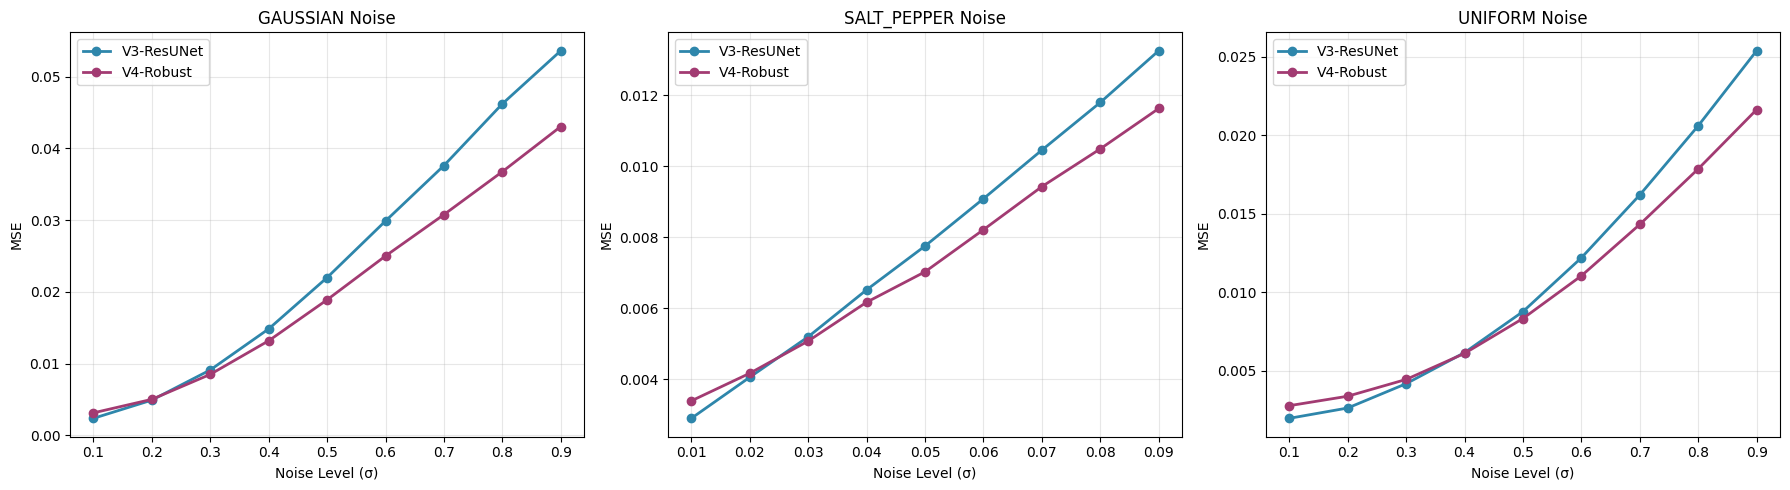

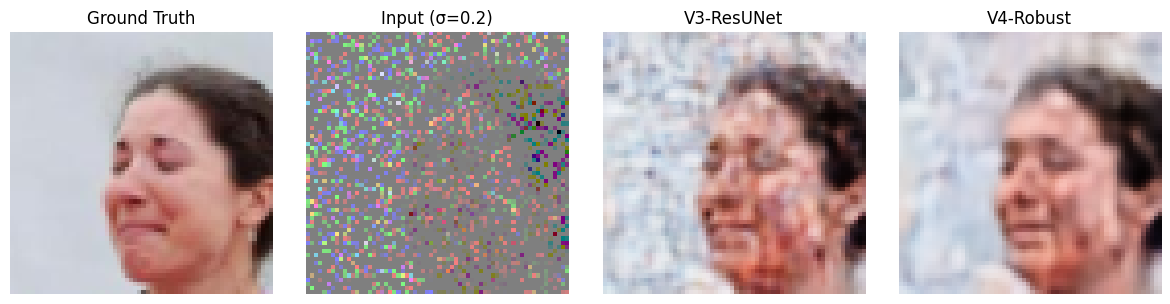

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import json
import time
import copy

# ============================================================================
# 1. CONFIGURATION
# ============================================================================
CONFIG = {
    'sparsity': 0.15,
    'img_size': 64,
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ============================================================================
# 2. UNIFIED DATASET
# ============================================================================
class UnifiedCelebADataset(Dataset):
    def __init__(self, root, split='test', sparsity=0.05, img_size=64):
        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        # Using download=True for convenience, switch to False if already downloaded
        try:
            self.data = datasets.CelebA(root=root, split=split, download=False, transform=self.transform)
        except:
            self.data = datasets.CelebA(root=root, split=split, download=True, transform=self.transform)
        self.sparsity = sparsity

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        full_image, attributes = self.data[idx]
        # Create mask
        mask = (torch.rand_like(full_image) < self.sparsity).float()
        sparse_image = full_image * mask
        
        # Ensure attributes are float tensors
        attributes = attributes.float()
        
        # Return format compatible with all models (now including attributes)
        return sparse_image, mask, full_image, attributes

# ============================================================================
# 3. SHARED BLOCKS
# ============================================================================
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm2d(c), nn.ReLU(), nn.Conv2d(c, c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(c), nn.ReLU(), nn.Conv2d(c, c, 3, 1, 1, bias=False)
        )
    def forward(self, x): return x + self.net(x)

# ============================================================================
# 4. MODEL VERSION 3: RES-UNET (Deep Regression Benchmark)
# ============================================================================
class ResUNet(nn.Module):
    def __init__(self, in_ch=6, out_ch=3):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(in_ch, 64, 4, 2, 1), nn.ReLU()) 
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU()) 
        self.enc3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU()) 
        self.enc4 = nn.Sequential(nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU()) 
        
        self.bottleneck = nn.Sequential(
            ResBlock(512), ResBlock(512), ResBlock(512), ResBlock(512)
        )
        
        self.dec4 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU()) 
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU()) 
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU()) 
        
        self.final = nn.Sequential(nn.Conv2d(64, out_ch, 3, 1, 1), nn.Tanh())

    def forward(self, x, mask):
        inp = torch.cat([x, mask], dim=1)
        e1 = self.enc1(inp)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        d4 = self.dec4(b)
        d3 = self.dec3(torch.cat([d4, e3], 1))
        d2 = self.dec2(torch.cat([d3, e2], 1))
        d1 = self.dec1(torch.cat([d2, e1], 1))
        return self.final(d1)
    
    def infer(self, sparse, mask, attributes=None):
        """Standardized inference method"""
        return self.forward(sparse, mask)

# ============================================================================
# 5. MODEL VERSION 4: ROBUST SEMANTIC MODEL (AdaIN-based, matches sota_v3_best.pth)
# ============================================================================
class AdaIN(nn.Module):
    """Adaptive Instance Normalization - The StyleGAN way to inject attributes"""
    def __init__(self, channels, embed_dim):
        super().__init__()
        self.channels = channels
        # Learn to predict scale (gamma) and shift (beta) from attributes
        self.linear = nn.Linear(embed_dim, channels * 2)

    def forward(self, x, attr_embed):
        # x: [B, C, H, W]
        # attr_embed: [B, embed_dim]
        
        # Calculate style parameters
        style = self.linear(attr_embed) # [B, 2*C]
        style = style.view(-1, 2, self.channels, 1, 1)
        gamma, beta = style[:, 0], style[:, 1]
        
        # Normalize x
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-8
        norm_x = (x - mean) / std
        
        # Modulate
        return gamma * norm_x + beta

class AdaINResBlock(nn.Module):
    def __init__(self, c, embed_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.conv2 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.adain1 = AdaIN(c, embed_dim)
        self.adain2 = AdaIN(c, embed_dim)
        self.act = nn.ReLU()
        
    def forward(self, x, attr_embed):
        residual = x
        
        out = self.conv1(x)
        out = self.act(self.adain1(out, attr_embed)) 
        
        out = self.conv2(out)
        out = self.adain2(out, attr_embed) 
        
        return self.act(out + residual)

class RobustEncoder(nn.Module):
    def __init__(self, input_channels=6, latent_channels=1024, attr_dim=40, embed_dim=256):
        super().__init__()
        # Standard convolutions
        self.entry = nn.Sequential(nn.Conv2d(input_channels, 64, 4, 2, 1), nn.ReLU())
        self.layer1 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.layer2 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        
        # We use AdaIN blocks here to condition encoder on attributes
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        
        self.exit = nn.Conv2d(256, latent_channels, 4, 2, 1) 

    def forward(self, x, mask, attr_embed):
        # Concatenate mask (essential for robustness)
        if mask is not None: x = torch.cat([x, mask], dim=1)
        
        h = self.entry(x)
        h = self.layer1(h)
        h = self.layer2(h)
        
        # Inject attributes via AdaIN (Gating) rather than Concatenation
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        
        return self.exit(h)

class RobustDecoder(nn.Module):
    def __init__(self, latent_channels=1024, embed_dim=256):
        super().__init__()
        
        self.layer1 = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        # Decoder also uses AdaIN to "paint" the attributes onto the features
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        
        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.exit = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z, attr_embed):
        h = self.layer1(z)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        h = self.layer2(h)
        h = self.layer3(h)
        return self.exit(h)

class AttributeEmbedding(nn.Module):
    def __init__(self, attr_dim=40, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(attr_dim, 128), nn.ReLU(),
            nn.Linear(128, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    def forward(self, x): return self.net(x)

class AttributePredictor(nn.Module):
    def __init__(self, latent_channels, attr_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(latent_channels, 128), nn.ReLU(),
            nn.Linear(128, attr_dim), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class SOTARobustModel(nn.Module):
    def __init__(self, latent_dim=1024, attr_dim=40):
        super().__init__()
        embed_dim = 256
        self.attr_embedding = AttributeEmbedding(attr_dim, embed_dim)
        self.encoder_x = RobustEncoder(6, latent_dim, attr_dim, embed_dim)
        self.encoder_s = RobustEncoder(3, latent_dim, attr_dim, embed_dim)
        self.decoder = RobustDecoder(latent_dim, embed_dim)
        self.attr_predictor = AttributePredictor(latent_dim, attr_dim)
        
    def forward(self, x, s, training_dropout=False):
        # 1. Get Attributes
        attr = s['attributes']
        attr_embed = self.attr_embedding(attr)
        
        # 2. ATTRIBUTE DROPOUT (The Robustness Fix)
        # If we are training and hit the probability, we ZERO out the attribute embedding.
        # For inference, we can optionally test with zeros to measure robustness
        if training_dropout and np.random.random() < 0.5:  # Using 0.5 as default
            used_embed = torch.zeros_like(attr_embed)
        else:
            used_embed = attr_embed
            
        # 3. Encode & Decode
        z_x = self.encoder_x(x['sparse_image'], x['mask'], used_embed)
        z_s = self.encoder_s(s['full_image'], None, used_embed)
        
        recon_x = self.decoder(z_x, used_embed)
        recon_s = self.decoder(z_s, used_embed)
        
        # 4. Predict Attributes (Always use z to ensure latent holds info)
        pred_attr_x = self.attr_predictor(z_x)
        
        return z_x, z_s, recon_x, recon_s, pred_attr_x
    
    def infer(self, sparse, mask, attributes=None):
        """Standardized inference method"""
        self.eval()
        with torch.no_grad():
            # If attributes provided, use them; otherwise predict or use zeros
            if attributes is None:
                # Create dummy attributes (all zeros) to test robustness
                attr_embed = torch.zeros(sparse.size(0), 256, device=sparse.device)
            else:
                attr_embed = self.attr_embedding(attributes)
            
            z_x = self.encoder_x(sparse, mask, attr_embed)
            recon = self.decoder(z_x, attr_embed)
            return recon

# ============================================================================
# 6. NOISE ROBUSTNESS LOGIC
# ============================================================================

def add_noise_to_sparse(sparse_image, mask, noise_type='gaussian', noise_level=0.1):
    noisy_sparse = sparse_image.clone()
    
    if noise_type == 'gaussian':
        noise = torch.randn_like(sparse_image) * noise_level
        noisy_sparse = sparse_image + noise * mask
        
    elif noise_type == 'salt_pepper':
        flip_mask = (torch.rand_like(sparse_image) < noise_level) * mask
        num_flips = int(flip_mask.sum().item())
        if num_flips > 0:
            random_values = torch.randint(0, 2, (num_flips,), device=sparse_image.device).float() * 2 - 1
            noisy_sparse[flip_mask > 0] = random_values
        
    elif noise_type == 'uniform':
        noise = (torch.rand_like(sparse_image) * 2 - 1) * noise_level
        noisy_sparse = sparse_image + noise * mask
    
    # Clamp to valid range
    noisy_sparse = torch.clamp(noisy_sparse, -1, 1)
    return noisy_sparse

def evaluate_models(models_dict, test_loader, device, noise_config, max_samples=1000):
    """
    Evaluates a dictionary of models: {'Name': model_instance}
    noise_config: dict mapping noise_type -> list of noise levels
    """
    results = {name: {} for name in models_dict.keys()}
    
    for name, model in models_dict.items():
        print(f"\nEvaluating {name}...")
        model.eval()
        results[name] = {nt: {} for nt in noise_config.keys()}
        
        for noise_type, noise_levels in noise_config.items():
            for level in noise_levels:
                mse_list = []
                sample_count = 0
                
                with torch.no_grad():
                    # UPDATED: Unpack attributes
                    for sparse, mask, full, attributes in test_loader:
                        if sample_count >= max_samples: break
                        
                        sparse = sparse.to(device)
                        mask = mask.to(device)
                        full = full.to(device)
                        attributes = attributes.to(device)
                        
                        noisy_sparse = add_noise_to_sparse(sparse, mask, noise_type, level)
                        
                        # UPDATED: Unified Inference Call with attributes
                        recon = model.infer(noisy_sparse, mask, attributes=attributes)
                        
                        # Metrics
                        recon_01 = torch.clamp((recon + 1) / 2, 0, 1)
                        full_01 = torch.clamp((full + 1) / 2, 0, 1)
                        mse_list.extend(F.mse_loss(recon_01, full_01, reduction='none').mean(dim=[1,2,3]).tolist())
                        sample_count += sparse.size(0)
                
                mean_mse = np.mean(mse_list)
                results[name][noise_type][level] = mean_mse
                print(f"  [{noise_type} | σ={level:.3f}] MSE: {mean_mse:.6f}")
                
    return results

def visualize_comparison(results, save_path='noise_comparison.png'):
    noise_types = list(results[list(results.keys())[0]].keys())
    model_names = list(results.keys())
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#28a745', '#9a2eab', '#FF5733']
    
    fig, axes = plt.subplots(1, len(noise_types), figsize=(6*len(noise_types), 5))
    if len(noise_types) == 1: axes = [axes]
    
    for idx, nt in enumerate(noise_types):
        ax = axes[idx]
        noise_levels = sorted(results[model_names[0]][nt].keys())
        
        for i, name in enumerate(model_names):
            mses = [results[name][nt][nl] for nl in noise_levels]
            ax.plot(noise_levels, mses, 'o-', linewidth=2, label=name, color=colors[i % len(colors)])
            
        ax.set_title(f"{nt.upper()} Noise")
        ax.set_xlabel("Noise Level (σ)")
        ax.set_ylabel("MSE")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Plot saved to {save_path}")

def visual_reconstruction(models_dict, dataset, device, noise_level=0.2):
    """Generates visual grid: Top=GT, Then rows for each model"""
    idx = np.random.randint(len(dataset))
    sparse, mask, full, attributes = dataset[idx] # Unpack 4
    sparse = sparse.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)
    full = full.unsqueeze(0).to(device)
    attributes = attributes.unsqueeze(0).to(device)
    
    noisy_sparse = add_noise_to_sparse(sparse, mask, 'gaussian', noise_level)
    
    imgs = []
    titles = []
    
    # 1. Ground Truth
    imgs.append(full)
    titles.append("Ground Truth")
    
    # 2. Noisy Input (Visualization)
    imgs.append(noisy_sparse)
    titles.append(f"Input (σ={noise_level})")
    
    # 3. Models
    for name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            recon = model.infer(noisy_sparse, mask, attributes=attributes)
            imgs.append(recon)
            titles.append(name)
            
    # Plotting
    fig, axes = plt.subplots(1, len(imgs), figsize=(3*len(imgs), 3))
    for i, ax in enumerate(axes):
        img_np = (imgs[i].squeeze().cpu().permute(1,2,0).numpy() + 1) / 2
        ax.imshow(np.clip(img_np, 0, 1))
        ax.set_title(titles[i])
        ax.axis('off')
        
    plt.tight_layout()
    plt.savefig("visual_reconstruction.png")
    print("Visual reconstruction saved.")

# ============================================================================
# 7. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    device = CONFIG['device']
    print(f"Running on {device}")
    
    # 1. Load Data
    print("Loading Dataset...")
    test_ds = UnifiedCelebADataset('./data', split='test', sparsity=CONFIG['sparsity'])
    test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)
    
    # 2. Initialize Models
    print("Initializing Models...")
    models = {
        'V3-ResUNet': ResUNet().to(device),
        'V4-Robust': SOTARobustModel(latent_dim=1024, attr_dim=40).to(device),
    }
    
    # 3. Load Weights
    try:
        if os.path.exists('sota_resunet.pth'):
            models['V3-ResUNet'].load_state_dict(torch.load('sota_resunet.pth'))
            print("Loaded V3-ResUNet weights")
        if os.path.exists('sota_v3_best.pth'):
            models['V4-Robust'].load_state_dict(torch.load('sota_v3_best.pth'))
            print("Loaded sota_best_manifold weights")
        print("Weights check complete.")
    except Exception as e:
        print(f"Weight loading warning: {e}. Using random weights for demonstration.")

    # 4. Define Noise Configuration (Different ranges for different noise types)
    noise_config = {
        'gaussian': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
        'salt_pepper': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09],
        'uniform': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    }
    
    # 5. Run Evaluation
    results = evaluate_models(models, test_loader, device, noise_config, max_samples=200)
    
    # 6. Visualize
    visualize_comparison(results)
    visual_reconstruction(models, test_ds, device)
    
    # 7. Save JSON
    with open('robustness_results.json', 'w') as f:
        # Convert numpy floats to native float for JSON serialization
        clean_results = {}
        for m in results:
            clean_results[m] = {}
            for nt in results[m]:
                clean_results[m][nt] = {str(k): float(v) for k, v in results[m][nt].items()}
        json.dump(clean_results, f, indent=2)
    print("Done.")

## Four Metrics

In [7]:
# ============================================================================
# HOMEOMORPHISM VERIFICATION FOR CELEBA MANIFOLD MODEL
# Four Metrics: β₀, Trust, Sliced Wasserstein, Alignment, In-Class Continuity
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
from tqdm import tqdm
import json
from scipy.stats import wasserstein_distance
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import sys
import os

# Import from your training code
# Note: These should be imported from your training file
# For now, we'll define CONFIG here as a workaround
CONFIG = {
    'sparsity': 0.05,
    'img_size': 64,       
    'batch_size': 64,
    'epochs': 60,
    'lr': 2e-4,           
    'latent_dim': 1024,
    'attr_dim': 40,
    'patience': 8,
    'consistency_w': 1.0,  
    'attr_weight': 0.1, 
    'attr_dropout': 0.5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ============================================================================
# MODEL COMPONENTS (Imported from training code)
# ============================================================================
import torch.nn as nn
from torchvision import datasets, transforms

class EnhancedCelebADataset(torch.utils.data.Dataset):
    def __init__(self, root, split='train', sparsity=0.05, img_size=64):
        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        try:
            self.data = datasets.CelebA(root=root, split=split, download=False, transform=self.transform)
        except:
            self.data = datasets.CelebA(root=root, split=split, download=True, transform=self.transform)
        self.sparsity = sparsity

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        full_image, attributes = self.data[idx]
        mask = (torch.rand_like(full_image) < self.sparsity).float()
        sparse_image = full_image * mask
        attributes = attributes.float()
        x = {'sparse_image': sparse_image, 'mask': mask}
        s = {'full_image': full_image, 'attributes': attributes} 
        return x, s

class AdaIN(nn.Module):
    def __init__(self, channels, embed_dim):
        super().__init__()
        self.channels = channels
        self.linear = nn.Linear(embed_dim, channels * 2)

    def forward(self, x, attr_embed):
        style = self.linear(attr_embed)
        style = style.view(-1, 2, self.channels, 1, 1)
        gamma, beta = style[:, 0], style[:, 1]
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-8
        norm_x = (x - mean) / std
        return gamma * norm_x + beta

class AdaINResBlock(nn.Module):
    def __init__(self, c, embed_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.conv2 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.adain1 = AdaIN(c, embed_dim)
        self.adain2 = AdaIN(c, embed_dim)
        self.act = nn.ReLU()
        
    def forward(self, x, attr_embed):
        residual = x
        out = self.conv1(x)
        out = self.act(self.adain1(out, attr_embed)) 
        out = self.conv2(out)
        out = self.adain2(out, attr_embed) 
        return self.act(out + residual)

class RobustEncoder(nn.Module):
    def __init__(self, input_channels=6, latent_channels=512, attr_dim=40, embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(nn.Conv2d(input_channels, 64, 4, 2, 1), nn.ReLU())
        self.layer1 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.layer2 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        self.exit = nn.Conv2d(256, latent_channels, 4, 2, 1) 

    def forward(self, x, mask, attr_embed):
        if mask is not None: x = torch.cat([x, mask], dim=1)
        h = self.entry(x)
        h = self.layer1(h)
        h = self.layer2(h)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        return self.exit(h)

class RobustDecoder(nn.Module):
    def __init__(self, latent_channels=512, embed_dim=256):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.exit = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z, attr_embed):
        h = self.layer1(z)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        h = self.layer2(h)
        h = self.layer3(h)
        return self.exit(h)

class AttributeEmbedding(nn.Module):
    def __init__(self, attr_dim=40, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(attr_dim, 128), nn.ReLU(),
            nn.Linear(128, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    def forward(self, x): return self.net(x)

class AttributePredictor(nn.Module):
    def __init__(self, latent_channels, attr_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(latent_channels, 128), nn.ReLU(),
            nn.Linear(128, attr_dim), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class SOTARobustModel(nn.Module):
    def __init__(self):
        super().__init__()
        embed_dim = 256
        self.attr_embedding = AttributeEmbedding(CONFIG['attr_dim'], embed_dim)
        self.encoder_x = RobustEncoder(6, CONFIG['latent_dim'], CONFIG['attr_dim'], embed_dim)
        self.encoder_s = RobustEncoder(3, CONFIG['latent_dim'], CONFIG['attr_dim'], embed_dim)
        self.decoder = RobustDecoder(CONFIG['latent_dim'], embed_dim)
        self.attr_predictor = AttributePredictor(CONFIG['latent_dim'], CONFIG['attr_dim'])
        
    def forward(self, x, s, training_dropout=False):
        attr = s['attributes']
        attr_embed = self.attr_embedding(attr)
        
        if training_dropout and np.random.random() < CONFIG['attr_dropout']:
            used_embed = torch.zeros_like(attr_embed)
        else:
            used_embed = attr_embed
            
        z_x = self.encoder_x(x['sparse_image'], x['mask'], used_embed)
        z_s = self.encoder_s(s['full_image'], None, used_embed)
        
        recon_x = self.decoder(z_x, used_embed)
        recon_s = self.decoder(z_s, used_embed)
        
        pred_attr_x = self.attr_predictor(z_x)
        
        return z_x, z_s, recon_x, recon_s, pred_attr_x

# ============================================================================
# VERIFICATION METRICS
# ============================================================================


def compute_betti_0(latent_codes, kappa=10):
    """
    Compute β₀ (0-th Betti number) = number of connected components
    
    Theoretical Link: Detects violations of Topological Disjointness (μ → 0)
    
    β₀ = 1: Single connected manifold (unification verified)
    β₀ > 1: Disjoint components (unification failed)
    
    Args:
        latent_codes: (N, D) array of latent codes
        kappa: number of nearest neighbors for graph construction
    
    Returns:
        beta_0: number of connected components
        labels: component assignment for each point
    """
    N = len(latent_codes)
    
    # Build k-NN graph
    nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                         algorithm='auto', n_jobs=-1)
    nn.fit(latent_codes)
    distances, neighbors = nn.kneighbors(latent_codes)
    
    # Create adjacency matrix (undirected graph)
    row_indices = []
    col_indices = []
    
    for i in range(N):
        for j in neighbors[i, 1:]:  # Skip self
            row_indices.append(i)
            col_indices.append(j)
            row_indices.append(j)
            col_indices.append(i)
    
    # Create sparse adjacency matrix
    data = np.ones(len(row_indices))
    adjacency = csr_matrix((data, (row_indices, col_indices)), shape=(N, N))
    
    # Count connected components
    n_components, labels = connected_components(
        csgraph=adjacency,
        directed=False,
        return_labels=True
    )
    
    return n_components, labels


def compute_trust_score(latent_codes, attributes, kappa=5, attribute_threshold=0.5):
    """
    METRIC 1: Trust Score (τ_t ≥ 0.80)
    
    For CelebA: Measures if k-nearest neighbors share similar attributes
    Uses average attribute similarity instead of exact label matching
    
    Theoretical Link: Empirical proxy for local preservation and injectivity 
    (c₁ > 0) from Theorem 2 and Proposition 1(i).
    
    Args:
        latent_codes: (N, D) array of latent representations
        attributes: (N, A) array of binary attributes (40 attributes for CelebA)
        kappa: number of nearest neighbors
        attribute_threshold: minimum similarity to count as "same"
    
    Returns:
        trust_score: average attribute similarity with neighbors
    """
    N = len(latent_codes)
    
    # Build k-NN graph
    nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                         algorithm='auto', n_jobs=-1)
    nn.fit(latent_codes)
    _, neighbors = nn.kneighbors(latent_codes)
    neighbors = neighbors[:, 1:]  # Exclude self
    
    # Compute trust: average attribute similarity with neighbors
    trust_scores = []
    for i in range(N):
        neighbor_attrs = attributes[neighbors[i]]
        # Compute Jaccard similarity or Hamming distance
        similarities = np.mean(neighbor_attrs == attributes[i], axis=1)
        trust_scores.append(np.mean(similarities))
    
    return np.mean(trust_scores)


def compute_sliced_wasserstein(X, Y, n_projections=100):
    """
    METRIC 2: Sliced Wasserstein-2 Discrepancy (τ_w ≤ 0.30)
    
    Theoretical Link: Proxy for global geometric alignment from Proposition 1(ii).
    
    Measures: Transport cost between distributions P_z^[sparse] and P_z^[full]
    
    Args:
        X: (N1, D) samples from distribution 1 (sparse)
        Y: (N2, D) samples from distribution 2 (full)
        n_projections: number of random 1D projections
    
    Returns:
        sliced_w2: Sliced Wasserstein-2 distance
    """
    D = X.shape[1]
    distances = []
    
    for _ in range(n_projections):
        # Random direction on unit sphere
        theta = np.random.randn(D)
        theta = theta / np.linalg.norm(theta)
        
        # Project both distributions
        X_proj = X @ theta
        Y_proj = Y @ theta
        
        # Compute 1D Wasserstein distance
        w1d = wasserstein_distance(X_proj, Y_proj)
        distances.append(w1d ** 2)
    
    return np.sqrt(np.mean(distances))


def compute_alignment_error(latent_codes_sparse, latent_codes_full, 
                           attributes_sparse, attributes_full,
                           distance_metric='euclidean', n_bins=5):
    """
    METRIC 3: Alignment Error (τ_a ≤ 0.15 for Euclidean, ≤ 0.10 for Cosine)
    
    For CelebA: Group by attribute similarity bins instead of discrete classes
    
    Theoretical Link: Direct measure of coordinate system matching. Confirms that
    paired encodings (sparse and full of the SAME sample) map to the SAME point.
    
    Args:
        latent_codes_sparse: (N, D) from sparse encoder (encoder_x)
        latent_codes_full: (N, D) from full encoder (encoder_s) - SAME samples
        attributes_sparse: (N, A) attributes for sparse data
        attributes_full: (N, A) attributes for full data (should match)
        distance_metric: 'euclidean' or 'cosine'
        n_bins: number of attribute bins for grouping
    
    Returns:
        avg_error: average alignment error
        per_bin_error: dict mapping bin_id -> alignment error
        global_error: alignment error across all samples
    """
    N = len(latent_codes_sparse)
    
    # Compute global error first
    if distance_metric == 'euclidean':
        global_error = float(np.mean(np.linalg.norm(
            latent_codes_sparse - latent_codes_full, axis=1
        )))
    elif distance_metric == 'cosine':
        global_error = float(np.mean(np.diag(cosine_distances(
            latent_codes_sparse, latent_codes_full
        ))))
    else:
        raise ValueError(f"Unknown distance metric: {distance_metric}")
    
    # Group samples by attribute similarity
    # Use number of positive attributes as a simple binning strategy
    attr_counts = np.sum(attributes_sparse > 0.5, axis=1)
    bins = np.linspace(0, attributes_sparse.shape[1], n_bins + 1)
    bin_indices = np.digitize(attr_counts, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    per_bin_error = {}
    
    for bin_id in range(n_bins):
        mask = (bin_indices == bin_id)
        
        if np.sum(mask) == 0:
            continue
        
        sparse_bin = latent_codes_sparse[mask]
        full_bin = latent_codes_full[mask]
        
        # Compute distance between paired encodings
        if distance_metric == 'euclidean':
            distances = np.linalg.norm(sparse_bin - full_bin, axis=1)
        else:  # cosine
            distances = np.diag(cosine_distances(sparse_bin, full_bin))
        
        per_bin_error[int(bin_id)] = float(np.mean(distances))
    
    # Average across all bins
    avg_error = np.mean(list(per_bin_error.values())) if per_bin_error else global_error
    
    return avg_error, per_bin_error, global_error


def compute_attribute_based_continuity(latent_codes, attributes, kappa=5, n_groups=10):
    """
    METRIC 4: Attribute-Based Continuity (τ_c ≥ 0.80)
    
    For CelebA: Measures continuity within attribute-based groups
    Groups samples by similar attribute patterns
    
    Theoretical Link: Ensures bounded stretching (c₂ < ∞) within the manifold
    
    Args:
        latent_codes: (N, D) latent representations from ONE encoder only
        attributes: (N, A) binary attributes
        kappa: number of nearest neighbors
        n_groups: number of attribute-based groups
    
    Returns:
        continuity_score: average compactness score
        per_group_continuity: dict mapping group_id to continuity score
    """
    N = len(latent_codes)
    
    # Group samples by attribute patterns using k-means on attributes
    from sklearn.cluster import KMeans
    
    kmeans = KMeans(n_clusters=n_groups, random_state=42, n_init=10)
    group_labels = kmeans.fit_predict(attributes)
    
    per_group_continuity = {}
    
    for g in range(n_groups):
        mask = (group_labels == g)
        group_latents = latent_codes[mask]
        
        if len(group_latents) < kappa + 1:
            continue
        
        # Within this group, build k-NN
        nn = NearestNeighbors(n_neighbors=kappa+1, metric='euclidean', 
                             algorithm='auto', n_jobs=-1)
        nn.fit(group_latents)
        distances, _ = nn.kneighbors(group_latents)
        distances = distances[:, 1:]  # Exclude self
        
        # Measure compactness via coefficient of variation (CV)
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)
        
        # Continuity score: lower CV = more compact
        cv = std_dist / (mean_dist + 1e-8)
        continuity = 1.0 / (1.0 + cv)
        
        per_group_continuity[int(g)] = float(continuity)
    
    avg_continuity = np.mean(list(per_group_continuity.values()))
    return avg_continuity, per_group_continuity


def verify_celeba_homeomorphism(model, dataset_train, dataset_val, 
                                sparsity_levels=[0.05],
                                kappa=5, device='cpu', n_projections=100,
                                distance_metric='euclidean',
                                max_samples=5000):
    """
    Verify Topological Unification (Theorem 1) for CelebA Manifold Model
    
    THEORETICAL FRAMEWORK:
    
    Theorem 1 (Topological Unification):
        Requires (i) Local homeomorphism and (ii) Global connectivity
    
    Theorem 2 (Bi-Lipschitz Sufficiency):
        (c₁, c₂)-bi-Lipschitz encoder ⟹ homeomorphism
    
    Proposition 1 (Metric-Theoretical Bridge):
        Violations manifest as:
        (i) Manifold Collapse (c₁→0) ⟹ Low Trust Score
        (ii) Geometric Misalignment ⟹ High Wasserstein Distance
        (iii) Topological Disjointness (μ→0) ⟹ High Alignment Error
        (iv) Metric Distortion (c₂→∞) ⟹ Low Continuity
    
    VERIFICATION PROTOCOL (FOUR METRICS):
        ✓ Metric 0: β₀ = 1 - Topological connectivity
        ✓ Metric 1: Trust Score (τ_t ≥ 0.80) - Local preservation (c₁ > 0)
        ✓ Metric 2: Sliced W₂ (τ_w ≤ 0.30) - Global alignment (μ > 0)
        ✓ Metric 3: Alignment Error (τ_a ≤ 0.15/0.10) - Coordinate matching
        ✓ Metric 4: Continuity (τ_c ≥ 0.80) - Manifold compactness (c₂ < ∞)
    
    Args:
        model: Trained SOTARobustModel
        dataset_train: EnhancedCelebADataset for training
        dataset_val: EnhancedCelebADataset for validation
        sparsity_levels: List of sparsity ratios to test
        kappa: Number of nearest neighbors
        device: Computing device
        n_projections: Random projections for Sliced Wasserstein
        distance_metric: 'euclidean' or 'cosine' for alignment error
        max_samples: Maximum samples to use (for computational efficiency)
    
    Returns:
        results: Dictionary with all metrics per sparsity level
    """
    print("\n" + "="*80)
    print("HOMEOMORPHISM VERIFICATION - CELEBA MANIFOLD MODEL")
    print("="*80)
    print(f"Latent dimension: {model.encoder_x.exit.out_channels} (spatial)")
    print(f"Sparsity levels: {sparsity_levels}")
    print(f"κ (neighbors): {kappa}")
    print(f"Distance metric: {distance_metric}")
    print(f"Max samples per split: {max_samples}")
    print("="*80)
    
    print("\nTHEORETICAL JUSTIFICATION:")
    print("  Theorem 1: Topological Unification requires:")
    print("    (i) Local homeomorphism (each encoder)")
    print("    (ii) Global connectivity (non-trivial overlap)")
    print()
    print("  Proposition 1: Violations manifest as:")
    print("    (i) Collapse (c₁→0) ⟹ Low Trust")
    print("    (ii) Misalignment ⟹ High W₂")
    print("    (iii) Disjointness (μ→0) ⟹ High Alignment Error")
    print("    (iv) Distortion (c₂→∞) ⟹ Low Continuity")
    print("="*80)
    
    print("\nVERIFICATION METRICS:")
    print("  0. β₀ = 1 - Topological connectivity check")
    print("  1. Trust Score (τ_t ≥ 0.80) - Local preservation (c₁ > 0)")
    print("  2. Sliced W₂ (τ_w ≤ 0.30) - Global distribution alignment (μ > 0)")
    print("  3. Alignment Error (τ_a ≤ 0.15/0.10) - Coordinate matching")
    print("  4. Continuity (τ_c ≥ 0.80) - Manifold compactness (SPARSE only)")
    print("="*80)
    
    model.eval()
    model.to(device)
    
    results = {}
    
    for sparsity in sparsity_levels:
        print(f"\n{'='*80}")
        print(f"EVALUATING AT ρ = {sparsity:.2f} ({sparsity:.0%} visible pixels)")
        print(f"{'='*80}")
        
        # ====================================================================
        # ENCODE TRAINING DATA
        # ====================================================================
        print(f"\nEncoding TRAINING samples...")
        
        # Limit samples for computational efficiency
        train_indices = np.random.choice(len(dataset_train), 
                                        min(max_samples, len(dataset_train)), 
                                        replace=False)
        
        latent_codes_train_sparse = []
        latent_codes_train_full = []
        attributes_train = []
        
        train_loader = DataLoader(
            torch.utils.data.Subset(dataset_train, train_indices),
            batch_size=64, shuffle=False, num_workers=0
        )
        
        with torch.no_grad():
            for x, s in tqdm(train_loader, desc="Train Encoding", leave=False):
                sparse_image = x['sparse_image'].to(device)
                mask = x['mask'].to(device)
                full_image = s['full_image'].to(device)
                attr = s['attributes'].to(device)
                
                x_in = {'sparse_image': sparse_image, 'mask': mask}
                s_in = {'full_image': full_image, 'attributes': attr}
                
                # Get embeddings (no dropout during evaluation)
                attr_embed = model.attr_embedding(attr)
                
                # Encode sparse and full
                z_sparse = model.encoder_x(sparse_image, mask, attr_embed)
                z_full = model.encoder_s(full_image, None, attr_embed)
                
                # Flatten spatial dimensions
                z_sparse_flat = z_sparse.view(z_sparse.size(0), -1)
                z_full_flat = z_full.view(z_full.size(0), -1)
                
                latent_codes_train_sparse.append(z_sparse_flat.cpu().numpy())
                latent_codes_train_full.append(z_full_flat.cpu().numpy())
                attributes_train.append(attr.cpu().numpy())
        
        latent_codes_train_sparse = np.vstack(latent_codes_train_sparse)
        latent_codes_train_full = np.vstack(latent_codes_train_full)
        attributes_train = np.vstack(attributes_train)
        
        # ====================================================================
        # ENCODE VALIDATION DATA
        # ====================================================================
        print(f"Encoding VALIDATION samples...")
        
        val_indices = np.random.choice(len(dataset_val), 
                                      min(max_samples, len(dataset_val)), 
                                      replace=False)
        
        latent_codes_val_sparse = []
        latent_codes_val_full = []
        attributes_val = []
        
        val_loader = DataLoader(
            torch.utils.data.Subset(dataset_val, val_indices),
            batch_size=64, shuffle=False, num_workers=0
        )
        
        with torch.no_grad():
            for x, s in tqdm(val_loader, desc="Val Encoding", leave=False):
                sparse_image = x['sparse_image'].to(device)
                mask = x['mask'].to(device)
                full_image = s['full_image'].to(device)
                attr = s['attributes'].to(device)
                
                x_in = {'sparse_image': sparse_image, 'mask': mask}
                s_in = {'full_image': full_image, 'attributes': attr}
                
                attr_embed = model.attr_embedding(attr)
                
                z_sparse = model.encoder_x(sparse_image, mask, attr_embed)
                z_full = model.encoder_s(full_image, None, attr_embed)
                
                z_sparse_flat = z_sparse.view(z_sparse.size(0), -1)
                z_full_flat = z_full.view(z_full.size(0), -1)
                
                latent_codes_val_sparse.append(z_sparse_flat.cpu().numpy())
                latent_codes_val_full.append(z_full_flat.cpu().numpy())
                attributes_val.append(attr.cpu().numpy())
        
        latent_codes_val_sparse = np.vstack(latent_codes_val_sparse)
        latent_codes_val_full = np.vstack(latent_codes_val_full)
        attributes_val = np.vstack(attributes_val)
        
        print(f"\nEncoded shapes:")
        print(f"  Train Sparse: {latent_codes_train_sparse.shape}")
        print(f"  Train Full:   {latent_codes_train_full.shape}")
        print(f"  Val Sparse:   {latent_codes_val_sparse.shape}")
        print(f"  Val Full:     {latent_codes_val_full.shape}")
        
        N_train = len(latent_codes_train_sparse)
        N_val = len(latent_codes_val_sparse)
        
        # ====================================================================
        # METRIC 0: β₀ (Topological Connectivity Check)
        # ====================================================================
        print(f"\n[0/4] Computing β₀ (connectivity check)...")
        
        # Combine ALL data: train_sparse, train_full, val_sparse, val_full
        latent_codes_all = np.vstack([
            latent_codes_train_sparse,
            latent_codes_train_full,
            latent_codes_val_sparse,
            latent_codes_val_full
        ])
        
        beta_0, component_labels = compute_betti_0(latent_codes_all, kappa=10)
        
        print(f"  β₀ = {beta_0}")
        if beta_0 == 1:
            print(f"  ✓ Single connected manifold (Theorem 1(ii) satisfied)")
        else:
            print(f"  ✗ {beta_0} disconnected components (μ→0 violation)")
            unique_components, counts = np.unique(component_labels, return_counts=True)
            print(f"  Component sizes: {dict(zip(unique_components, counts))}")
        
        # ====================================================================
        # METRIC 1: TRUST SCORE (Local Preservation)
        # ====================================================================
        print(f"\n[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...")
        
        # Compute trust on SPARSE encodings (combined train+val)
        latent_codes_sparse_all = np.vstack([latent_codes_train_sparse, 
                                             latent_codes_val_sparse])
        attributes_all = np.vstack([attributes_train, attributes_val])
        
        trust_score = compute_trust_score(latent_codes_sparse_all, 
                                         attributes_all, kappa=kappa)
        
        print(f"  Trust Score: {trust_score:.4f}")
        if trust_score >= 0.80:
            print(f"  ✓ Local preservation verified (c₁ > 0)")
        else:
            print(f"  ✗ Manifold collapse detected (c₁→0 violation)")
        
        # ====================================================================
        # METRIC 2: SLICED WASSERSTEIN (Global Alignment)
        # ====================================================================
        print(f"\n[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...")
        
        # Compare SPARSE vs FULL encodings (using training data)
        max_w2_samples = min(2000, N_train)
        if N_train > max_w2_samples:
            idx = np.random.choice(N_train, max_w2_samples, replace=False)
            sparse_sample = latent_codes_train_sparse[idx]
            full_sample = latent_codes_train_full[idx]
        else:
            sparse_sample = latent_codes_train_sparse
            full_sample = latent_codes_train_full
        
        w2_distance = compute_sliced_wasserstein(sparse_sample, full_sample, 
                                                 n_projections=n_projections)
        
        print(f"  Sliced W₂ (Sparse↔Full): {w2_distance:.4f}")
        if w2_distance <= 0.30:
            print(f"  ✓ Global alignment verified (distributions overlap)")
        else:
            print(f"  ✗ Geometric misalignment detected")
        
        # ====================================================================
        # METRIC 3: ALIGNMENT ERROR (Coordinate Matching/Merger)
        # ====================================================================
        threshold_align = 0.15 if distance_metric == 'euclidean' else 0.10
        print(f"\n[3/4] Computing ALIGNMENT ERROR (τ_a ≤ {threshold_align})...")
        print(f"  Distance metric: {distance_metric}")
        
        # Compute on COMBINED train+val for robust statistics
        latent_codes_sparse_all = np.vstack([latent_codes_train_sparse, 
                                             latent_codes_val_sparse])
        latent_codes_full_all = np.vstack([latent_codes_train_full, 
                                           latent_codes_val_full])
        attributes_all = np.vstack([attributes_train, attributes_val])
        
        alignment_error, per_bin_error, global_error = compute_alignment_error(
            latent_codes_sparse_all,
            latent_codes_full_all,
            attributes_all,
            attributes_all,  # Same attributes (same samples, different encodings)
            distance_metric=distance_metric
        )
        
        print(f"  Alignment Error (avg):  {alignment_error:.4f}")
        print(f"  Global Alignment Error: {global_error:.4f}")
        
        if alignment_error <= threshold_align:
            print(f"  ✓ Sparse and full map to THE SAME POINTS (perfect merger)")
        else:
            print(f"  ✗ Sparse and full use DIFFERENT coordinate systems")
        
        print(f"  Per-bin alignment errors:")
        for bin_id in sorted(per_bin_error.keys()):
            status = "✓" if per_bin_error[bin_id] <= threshold_align else "✗"
            print(f"    Bin {bin_id}: {per_bin_error[bin_id]:.4f} {status}")
        
        # ====================================================================
        # METRIC 4: CONTINUITY (Manifold Compactness - SPARSE ONLY)
        # ====================================================================
        print(f"\n[4/4] Computing ATTRIBUTE-BASED CONTINUITY (τ_c ≥ 0.80)...")
        print(f"  Measuring on SPARSE encodings only")
        
        continuity_score, per_group_continuity = compute_attribute_based_continuity(
            latent_codes_sparse_all,
            attributes_all,
            kappa=kappa,
            n_groups=10
        )
        
        print(f"  Continuity (Sparse): {continuity_score:.4f}")
        if continuity_score >= 0.80:
            print(f"  ✓ Manifold groups form coherent, compact clusters (c₂ < ∞)")
        else:
            print(f"  ⚠ Groups may be fragmented (metric distortion, c₂→∞)")
        
        print(f"  Per-group continuity (first 5):")
        for group_id in sorted(list(per_group_continuity.keys())[:5]):
            status = "✓" if per_group_continuity[group_id] >= 0.80 else "✗"
            print(f"    Group {group_id}: {per_group_continuity[group_id]:.4f} {status}")
        
        # ====================================================================
        # STORE RESULTS
        # ====================================================================
        results[sparsity] = {
            # Topology
            'beta_0': int(beta_0),
            
            # Metric 1: Trust (local preservation)
            'trust_score': float(trust_score),
            
            # Metric 2: Wasserstein (global alignment)
            'sliced_w2': float(w2_distance),
            
            # Metric 3: Alignment Error (coordinate matching)
            'alignment_error': float(alignment_error),
            'global_alignment_error': float(global_error),
            'per_bin_alignment': per_bin_error,
            
            # Metric 4: Continuity (manifold compactness - SPARSE)
            'continuity': float(continuity_score),
            'per_group_continuity': per_group_continuity,
            
            # Metadata
            'kappa': kappa,
            'distance_metric': distance_metric,
            'n_train': N_train,
            'n_val': N_val,
            'n_projections': n_projections
        }
        
        print(f"\n{'='*80}")
        print(f"SUMMARY FOR ρ = {sparsity:.2f}:")
        print(f"  β₀:              {beta_0}")
        print(f"  Trust Score:     {trust_score:.4f} {'✓' if trust_score >= 0.80 else '✗'}")
        print(f"  Sliced W₂:       {w2_distance:.4f} {'✓' if w2_distance <= 0.30 else '✗'}")
        print(f"  Alignment Error: {alignment_error:.4f} {'✓' if alignment_error <= threshold_align else '✗'}")
        print(f"  Continuity:      {continuity_score:.4f} {'✓' if continuity_score >= 0.80 else '✗'}")
        print(f"{'='*80}")
    
    # ========================================================================
    # FINAL VERIFICATION SUMMARY
    # ========================================================================
    threshold_align = 0.15 if distance_metric == 'euclidean' else 0.10
    
    print("\n" + "="*80)
    print("TOPOLOGICAL UNIFICATION VERIFICATION (THEOREM 1)")
    print("="*80)
    print(f"{'ρ':<8} {'β₀':<6} {'Trust':<10} {'W₂':<10} {'Align':<10} {'Cont':<10}")
    print("-"*80)
    for sparsity in sparsity_levels:
        r = results[sparsity]
        print(f"{sparsity:<8.2f} {r['beta_0']:<6} {r['trust_score']:<10.4f} "
              f"{r['sliced_w2']:<10.4f} {r['alignment_error']:<10.4f} "
              f"{r['continuity']:<10.4f}")
    print("="*80)
    
    print("\nTARGET THRESHOLDS:")
    print("  β₀ = 1             (single connected manifold)")
    print("  Trust ≥ 0.80       (local preservation, c₁ > 0)")
    print("  W₂ ≤ 0.30          (global distribution alignment, μ > 0)")
    print(f"  Align ≤ {threshold_align}          (coordinate matching, topological merger)")
    print("  Cont ≥ 0.80        (manifold compactness, c₂ < ∞, SPARSE only)")
    print("-"*80)
    
    # Check verification status
    all_pass = True
    
    for sparsity in sparsity_levels:
        r = results[sparsity]
        
        beta_pass = (r['beta_0'] == 1)
        trust_pass = (r['trust_score'] >= 0.80)
        w2_pass = (r['sliced_w2'] <= 0.30)
        align_pass = (r['alignment_error'] <= threshold_align)
        cont_pass = (r['continuity'] >= 0.80)
        
        status = "✓ PASS" if (beta_pass and trust_pass and w2_pass and 
                             align_pass and cont_pass) else "✗ FAIL"
        
        print(f"\nρ = {sparsity:.2f}: {status}")
        print(f"  β₀:        {'✓' if beta_pass else '✗'} (connectivity)")
        print(f"  Trust:     {'✓' if trust_pass else '✗'} (local preservation)")
        print(f"  W₂:        {'✓' if w2_pass else '✗'} (global alignment)")
        print(f"  Align:     {'✓' if align_pass else '✗'} (coordinate matching)")
        print(f"  Cont:      {'✓' if cont_pass else '✗'} (manifold compactness)")
        
        if not (beta_pass and trust_pass and w2_pass and align_pass and cont_pass):
            all_pass = False
    
    print("\n" + "="*80)
    if all_pass:
        print("VERIFICATION RESULT: ✓ THEOREM 1 SATISFIED (COMPLETE)")
        print("  - β₀ = 1: Single connected manifold")
        print("  - Trust ≥ 0.80: Local homeomorphism (Condition i, c₁ > 0)")
        print("  - W₂ ≤ 0.30: Sparse↔Full distributions co-located (Condition ii, μ > 0)")
        print(f"  - Align ≤ {threshold_align}: Sparse↔Full map to SAME points (perfect merger)")
        print("  - Cont ≥ 0.80: Manifold groups form compact clusters (c₂ < ∞)")
        print()
        print("CONCLUSION: Sparse and Full encodings form ONE UNIVERSAL MANIFOLD")
        print("            with TOPOLOGICALLY MERGED representations and")
        print("            COMPACT, SEMANTICALLY COHERENT attribute clusters.")
    else:
        print("VERIFICATION RESULT: ✗ THEOREM 1 VIOLATED")
        print("  Check individual metrics above for failure modes")
    print("="*80 + "\n")
    
    return results


def print_latex_table_celeba(results, kappa=5, distance_metric='euclidean'):
    """
    Generate LaTeX table for CelebA verification results
    """
    sparsity_levels = sorted(results.keys())
    threshold_align = 0.15 if distance_metric == 'euclidean' else 0.10
    
    print("\n" + "="*80)
    print("LaTeX Table (CelebA Verification):")
    print("="*80)
    print(r"\begin{table}[!htpb]")
    print(r"\centering")
    print(r"\caption{Topological Unification Verification - CelebA ($\kappa=" + str(kappa) + 
          r"$, " + distance_metric.capitalize() + r" distance)}")
    print(r"\label{tab:celeba_unification}")
    
    # Determine number of columns
    n_cols = len(sparsity_levels)
    col_spec = "l" + "c" * n_cols
    print(r"\begin{tabular}{" + col_spec + "}")
    print(r"\hline")
    
    # Header
    header = r"\textbf{Metric}"
    for rho in sparsity_levels:
        header += f" & $\\rho={rho:.2f}$"
    header += r" \\"
    print(header)
    print(r"\hline")
    
    # β₀
    beta_row = r"$\beta_0$ (connectivity)"
    for rho in sparsity_levels:
        val = results[rho]['beta_0']
        beta_row += f" & {val}"
    beta_row += r" \\"
    print(beta_row)
    
    # Trust
    trust_row = r"Trust $\tau_t$ ($\geq 0.80$)"
    for rho in sparsity_levels:
        val = results[rho]['trust_score']
        trust_row += f" & {val:.3f}"
    trust_row += r" \\"
    print(trust_row)
    
    # Sliced W₂
    w2_row = r"Sliced $W_2$ $\tau_w$ ($\leq 0.30$)"
    for rho in sparsity_levels:
        val = results[rho]['sliced_w2']
        w2_row += f" & {val:.3f}"
    w2_row += r" \\"
    print(w2_row)
    
    # Alignment Error
    align_row = f"Alignment $\\tau_a$ ($\\leq {threshold_align:.2f}$)"
    for rho in sparsity_levels:
        val = results[rho]['alignment_error']
        align_row += f" & {val:.3f}"
    align_row += r" \\"
    print(align_row)
    
    # Continuity
    cont_row = r"Continuity $\tau_c$ ($\geq 0.80$)"
    for rho in sparsity_levels:
        val = results[rho]['continuity']
        cont_row += f" & {val:.3f}"
    cont_row += r" \\"
    print(cont_row)
    
    print(r"\hline")
    print(r"\end{tabular}")
    print(r"\end{table}")
    print("="*80 + "\n")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == '__main__':
    print("="*80)
    print("HOMEOMORPHISM VERIFICATION - CELEBA MANIFOLD MODEL")
    print("Theorem 1: Topological Unification")
    print("Proposition 1: Metric-Theoretical Bridge")
    print("Four-Metric Verification: β₀, Trust, W₂, Alignment, Continuity")
    print("="*80 + "\n")
    
    # Load trained model
    print("Loading trained CelebA model...")
    model = SOTARobustModel()
    
    if os.path.exists('sota_v3_best.pth'):
        model.load_state_dict(torch.load('sota_v3_best.pth', map_location='cpu'))
        print("Loaded: sota_v3_best.pth")
    elif os.path.exists('sota_best_manifold.pth'):
        model.load_state_dict(torch.load('sota_best_manifold.pth', map_location='cpu'))
        print("Loaded: sota_best_manifold.pth")
    else:
        print("ERROR: No trained model found!")
        print("Please ensure 'sota_v3_best.pth' or 'sota_best_manifold.pth' exists.")
        sys.exit(1)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    print(f"Model loaded on {device}\n")
    
    # Run verification for multiple sparsity levels
    sparsity_levels = [0.05, 0.08, 0.10, 0.12, 0.15]
    
    # Choose distance metric: 'euclidean' or 'cosine'
    DISTANCE_METRIC = 'cosine'
    
    # We need to recreate datasets for each sparsity level
    # So we'll call the verification function directly with dataset creation inside
    results = {}
    
    for sparsity in sparsity_levels:
        print(f"\n{'='*80}")
        print(f"TESTING SPARSITY LEVEL: ρ = {sparsity:.2f}")
        print(f"{'='*80}")
        
        # Create datasets with this sparsity level
        train_ds = EnhancedCelebADataset('./data', split='train', sparsity=sparsity)
        val_ds = EnhancedCelebADataset('./data', split='valid', sparsity=sparsity)
        
        # Run verification for this sparsity level
        sparsity_results = verify_celeba_homeomorphism(
            model=model,
            dataset_train=train_ds,
            dataset_val=val_ds,
            sparsity_levels=[sparsity],  # Single sparsity per run
            kappa=5,
            device=device,
            n_projections=100,
            distance_metric=DISTANCE_METRIC,
            max_samples=5000
        )
        
        # Store results
        results.update(sparsity_results)
    
    # Generate LaTeX table
    print_latex_table_celeba(results, kappa=5, distance_metric=DISTANCE_METRIC)
    
    # Save results
    output_file = f'celeba_verification_results_{DISTANCE_METRIC}.json'
    with open(output_file, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"✓ Results saved to '{output_file}'")
    
    print("\n" + "="*80)
    print("VERIFICATION COMPLETE!")
    print("="*80)

HOMEOMORPHISM VERIFICATION - CELEBA MANIFOLD MODEL
Theorem 1: Topological Unification
Proposition 1: Metric-Theoretical Bridge
Four-Metric Verification: β₀, Trust, W₂, Alignment, Continuity

Loading trained CelebA model...
Loaded: sota_v3_best.pth
Model loaded on cuda


TESTING SPARSITY LEVEL: ρ = 0.05

HOMEOMORPHISM VERIFICATION - CELEBA MANIFOLD MODEL
Latent dimension: 1024 (spatial)
Sparsity levels: [0.05]
κ (neighbors): 5
Distance metric: cosine
Max samples per split: 5000

THEORETICAL JUSTIFICATION:
  Theorem 1: Topological Unification requires:
    (i) Local homeomorphism (each encoder)
    (ii) Global connectivity (non-trivial overlap)

  Proposition 1: Violations manifest as:
    (i) Collapse (c₁→0) ⟹ Low Trust
    (ii) Misalignment ⟹ High W₂
    (iii) Disjointness (μ→0) ⟹ High Alignment Error
    (iv) Distortion (c₂→∞) ⟹ Low Continuity

VERIFICATION METRICS:
  0. β₀ = 1 - Topological connectivity check
  1. Trust Score (τ_t ≥ 0.80) - Local preservation (c₁ > 0)
  2. Sliced W₂ 

Encoding VALIDATION samples...



Encoded shapes:
  Train Sparse: (5000, 16384)
  Train Full:   (5000, 16384)
  Val Sparse:   (5000, 16384)
  Val Full:     (5000, 16384)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.8770
  ✓ Local preservation verified (c₁ > 0)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0058
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  Alignment Error (avg):  0.0429
  Global Alignment Error: 0.0433
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-bin alignment errors:
    Bin 0: 0.0452 ✓
    Bin 1: 0.0424 ✓
    Bin 2: 0.0410 ✓

[4/4] Computing ATTRIBUTE-BASED CONTINUITY (τ_c ≥ 0.80)...
  Measuring on SPARSE encodings only
  Continuity (Sparse): 0.8877
  ✓ Manifold groups form coherent, compact clusters (c₂ < ∞)
  Per-group continuity (firs

Encoding VALIDATION samples...



Encoded shapes:
  Train Sparse: (5000, 16384)
  Train Full:   (5000, 16384)
  Val Sparse:   (5000, 16384)
  Val Full:     (5000, 16384)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.8732
  ✓ Local preservation verified (c₁ > 0)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0080
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  Alignment Error (avg):  0.0414
  Global Alignment Error: 0.0422
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-bin alignment errors:
    Bin 0: 0.0443 ✓
    Bin 1: 0.0412 ✓
    Bin 2: 0.0387 ✓

[4/4] Computing ATTRIBUTE-BASED CONTINUITY (τ_c ≥ 0.80)...
  Measuring on SPARSE encodings only
  Continuity (Sparse): 0.8893
  ✓ Manifold groups form coherent, compact clusters (c₂ < ∞)
  Per-group continuity (firs

...


Encoded shapes:
  Train Sparse: (5000, 16384)
  Train Full:   (5000, 16384)
  Val Sparse:   (5000, 16384)
  Val Full:     (5000, 16384)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.8711
  ✓ Local preservation verified (c₁ > 0)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0109
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  Alignment Error (avg):  0.0429
  Global Alignment Error: 0.0442
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-bin alignment errors:
    Bin 0: 0.0466 ✓
    Bin 1: 0.0430 ✓
    Bin 2: 0.0390 ✓

[4/4] Computing ATTRIBUTE-BASED CONTINUITY (τ_c ≥ 0.80)...
  Measuring on SPARSE encodings only
  Continuity (Sparse): 0.8851
  ✓ Manifold groups form coherent, compact clusters (c₂ < ∞)
  Per-group continuity (firs

Encoding VALIDATION samples...



Encoded shapes:
  Train Sparse: (5000, 16384)
  Train Full:   (5000, 16384)
  Val Sparse:   (5000, 16384)
  Val Full:     (5000, 16384)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.8685
  ✓ Local preservation verified (c₁ > 0)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0116
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  Alignment Error (avg):  0.0462
  Global Alignment Error: 0.0476
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-bin alignment errors:
    Bin 0: 0.0504 ✓
    Bin 1: 0.0462 ✓
    Bin 2: 0.0419 ✓

[4/4] Computing ATTRIBUTE-BASED CONTINUITY (τ_c ≥ 0.80)...
  Measuring on SPARSE encodings only
  Continuity (Sparse): 0.8855
  ✓ Manifold groups form coherent, compact clusters (c₂ < ∞)
  Per-group continuity (firs

Encoding VALIDATION samples...



Encoded shapes:
  Train Sparse: (5000, 16384)
  Train Full:   (5000, 16384)
  Val Sparse:   (5000, 16384)
  Val Full:     (5000, 16384)

[0/4] Computing β₀ (connectivity check)...
  β₀ = 1
  ✓ Single connected manifold (Theorem 1(ii) satisfied)

[1/4] Computing TRUST SCORE (τ_t ≥ 0.80)...
  Trust Score: 0.8657
  ✓ Local preservation verified (c₁ > 0)

[2/4] Computing SLICED WASSERSTEIN-2 (τ_w ≤ 0.30)...
  Sliced W₂ (Sparse↔Full): 0.0135
  ✓ Global alignment verified (distributions overlap)

[3/4] Computing ALIGNMENT ERROR (τ_a ≤ 0.1)...
  Distance metric: cosine
  Alignment Error (avg):  0.0546
  Global Alignment Error: 0.0552
  ✓ Sparse and full map to THE SAME POINTS (perfect merger)
  Per-bin alignment errors:
    Bin 0: 0.0586 ✓
    Bin 1: 0.0535 ✓
    Bin 2: 0.0516 ✓

[4/4] Computing ATTRIBUTE-BASED CONTINUITY (τ_c ≥ 0.80)...
  Measuring on SPARSE encodings only
  Continuity (Sparse): 0.8793
  ✓ Manifold groups form coherent, compact clusters (c₂ < ∞)
  Per-group continuity (firs

In [1]:
# ============================================================================
# CELEBA SPARSE RECOVERY PERFORMANCE EVALUATION
# Tests reconstruction quality across multiple sparsity levels
# Generates LaTeX table with MSE and PSNR metrics
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from tqdm import tqdm
import json
import os

# ============================================================================
# CONFIGURATION
# ============================================================================
CONFIG = {
    'img_size': 64,
    'batch_size': 64,
    'latent_dim': 1024,
    'attr_dim': 40,
    'attr_dropout': 0.5,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ============================================================================
# DATASET
# ============================================================================
class EnhancedCelebADataset(torch.utils.data.Dataset):
    def __init__(self, root, split='test', sparsity=0.05, img_size=64):
        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        try:
            self.data = datasets.CelebA(root=root, split=split, download=False, transform=self.transform)
        except:
            self.data = datasets.CelebA(root=root, split=split, download=True, transform=self.transform)
        self.sparsity = sparsity

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        full_image, attributes = self.data[idx]
        mask = (torch.rand_like(full_image) < self.sparsity).float()
        sparse_image = full_image * mask
        attributes = attributes.float()
        x = {'sparse_image': sparse_image, 'mask': mask}
        s = {'full_image': full_image, 'attributes': attributes}
        return x, s

# ============================================================================
# MODEL COMPONENTS
# ============================================================================
class AdaIN(nn.Module):
    def __init__(self, channels, embed_dim):
        super().__init__()
        self.channels = channels
        self.linear = nn.Linear(embed_dim, channels * 2)

    def forward(self, x, attr_embed):
        style = self.linear(attr_embed)
        style = style.view(-1, 2, self.channels, 1, 1)
        gamma, beta = style[:, 0], style[:, 1]
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-8
        norm_x = (x - mean) / std
        return gamma * norm_x + beta

class AdaINResBlock(nn.Module):
    def __init__(self, c, embed_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.conv2 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.adain1 = AdaIN(c, embed_dim)
        self.adain2 = AdaIN(c, embed_dim)
        self.act = nn.ReLU()
        
    def forward(self, x, attr_embed):
        residual = x
        out = self.conv1(x)
        out = self.act(self.adain1(out, attr_embed))
        out = self.conv2(out)
        out = self.adain2(out, attr_embed)
        return self.act(out + residual)

class RobustEncoder(nn.Module):
    def __init__(self, input_channels=6, latent_channels=512, attr_dim=40, embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(nn.Conv2d(input_channels, 64, 4, 2, 1), nn.ReLU())
        self.layer1 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.layer2 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        self.exit = nn.Conv2d(256, latent_channels, 4, 2, 1)

    def forward(self, x, mask, attr_embed):
        if mask is not None:
            x = torch.cat([x, mask], dim=1)
        h = self.entry(x)
        h = self.layer1(h)
        h = self.layer2(h)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        return self.exit(h)

class RobustDecoder(nn.Module):
    def __init__(self, latent_channels=512, embed_dim=256):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.exit = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z, attr_embed):
        h = self.layer1(z)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        h = self.layer2(h)
        h = self.layer3(h)
        return self.exit(h)

class AttributeEmbedding(nn.Module):
    def __init__(self, attr_dim=40, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(attr_dim, 128), nn.ReLU(),
            nn.Linear(128, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    def forward(self, x):
        return self.net(x)

class AttributePredictor(nn.Module):
    def __init__(self, latent_channels, attr_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(latent_channels, 128), nn.ReLU(),
            nn.Linear(128, attr_dim), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class SOTARobustModel(nn.Module):
    def __init__(self):
        super().__init__()
        embed_dim = 256
        self.attr_embedding = AttributeEmbedding(CONFIG['attr_dim'], embed_dim)
        self.encoder_x = RobustEncoder(6, CONFIG['latent_dim'], CONFIG['attr_dim'], embed_dim)
        self.encoder_s = RobustEncoder(3, CONFIG['latent_dim'], CONFIG['attr_dim'], embed_dim)
        self.decoder = RobustDecoder(CONFIG['latent_dim'], embed_dim)
        self.attr_predictor = AttributePredictor(CONFIG['latent_dim'], CONFIG['attr_dim'])
        
    def forward(self, x, s, training_dropout=False):
        attr = s['attributes']
        attr_embed = self.attr_embedding(attr)
        
        if training_dropout and np.random.random() < CONFIG['attr_dropout']:
            used_embed = torch.zeros_like(attr_embed)
        else:
            used_embed = attr_embed
            
        z_x = self.encoder_x(x['sparse_image'], x['mask'], used_embed)
        z_s = self.encoder_s(s['full_image'], None, used_embed)
        
        recon_x = self.decoder(z_x, used_embed)
        recon_s = self.decoder(z_s, used_embed)
        
        pred_attr_x = self.attr_predictor(z_x)
        
        return z_x, z_s, recon_x, recon_s, pred_attr_x

# ============================================================================
# EVALUATION FUNCTION
# ============================================================================
def evaluate_reconstruction(model, dataloader, device, sparsity_level):
    """
    Evaluate reconstruction quality on test set
    
    Returns:
        dict with MSE and PSNR metrics
    """
    model.eval()
    mses = []
    psnrs = []
    
    with torch.no_grad():
        for x, s in tqdm(dataloader, desc=f"Eval ρ={sparsity_level:.2f}", leave=False):
            # Move to device
            sparse = x['sparse_image'].to(device)
            mask = x['mask'].to(device)
            full = s['full_image'].to(device)
            attr = s['attributes'].to(device)
            
            x_in = {'sparse_image': sparse, 'mask': mask}
            s_in = {'full_image': full, 'attributes': attr}
            
            # Forward pass (no dropout)
            _, _, recon_x, _, _ = model(x_in, s_in, training_dropout=False)
            
            # Unnormalize to [0, 1]
            recon_01 = torch.clamp((recon_x + 1) / 2, 0, 1)
            full_01 = torch.clamp((full + 1) / 2, 0, 1)
            
            # Compute MSE per sample
            batch_mse = F.mse_loss(recon_01, full_01, reduction='none').mean(dim=[1, 2, 3])
            
            for mse_val in batch_mse:
                mse_item = mse_val.item()
                mses.append(mse_item)
                if mse_item > 0:
                    psnrs.append(-10 * np.log10(mse_item))
    
    avg_mse = np.mean(mses)
    avg_psnr = np.mean(psnrs)
    std_mse = np.std(mses)
    std_psnr = np.std(psnrs)
    
    return {
        'mse': avg_mse,
        'psnr': avg_psnr,
        'mse_std': std_mse,
        'psnr_std': std_psnr,
        'n_samples': len(mses)
    }

# ============================================================================
# MULTI-SPARSITY EVALUATION
# ============================================================================
def evaluate_multi_sparsity(model, data_root, sparsity_levels, device, batch_size=64):
    """
    Evaluate model across multiple sparsity levels
    
    Args:
        model: Trained model
        data_root: Path to CelebA data
        sparsity_levels: List of sparsity levels to test
        device: torch device
        batch_size: Batch size for evaluation
    
    Returns:
        dict: Results for each sparsity level
    """
    print("="*80)
    print("CELEBA SPARSE RECOVERY PERFORMANCE EVALUATION")
    print("="*80)
    print(f"Model: {model.__class__.__name__}")
    print(f"Sparsity levels: {sparsity_levels}")
    print(f"Device: {device}")
    print("="*80 + "\n")
    
    results = {}
    
    for sparsity in sparsity_levels:
        print(f"\n{'='*60}")
        print(f"Evaluating at ρ = {sparsity:.2f} ({sparsity:.0%} visible pixels)")
        print(f"{'='*60}")
        
        # Create dataset for this sparsity level
        test_dataset = EnhancedCelebADataset(data_root, split='test', sparsity=sparsity)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                                shuffle=False, num_workers=4)
        
        print(f"Test samples: {len(test_dataset)}")
        
        # Evaluate
        metrics = evaluate_reconstruction(model, test_loader, device, sparsity)
        
        # Store results
        results[sparsity] = metrics
        
        # Print results
        print(f"\nResults for ρ = {sparsity:.2f}:")
        print(f"  MSE:  {metrics['mse']:.6f} ± {metrics['mse_std']:.6f}")
        print(f"  PSNR: {metrics['psnr']:.2f} ± {metrics['psnr_std']:.2f} dB")
        print(f"  Samples: {metrics['n_samples']}")
        
        # Quality assessment
        if metrics['mse'] <= 0.005:
            print(f"  ✓ Excellent quality (MSE ≤ 0.005)")
        elif metrics['mse'] <= 0.010:
            print(f"  ✓ Good quality (MSE ≤ 0.010)")
        elif metrics['mse'] <= 0.020:
            print(f"  ⚠ Acceptable quality (MSE ≤ 0.020)")
        else:
            print(f"  ✗ Poor quality (MSE > 0.020)")
    
    return results

# ============================================================================
# LATEX TABLE GENERATION
# ============================================================================
def print_performance_table(results, model_name="SOTARobustModel"):
    """
    Generate LaTeX table for reconstruction performance
    
    Args:
        results: Dict of results per sparsity level
        model_name: Name of the model for caption
    """
    sparsity_levels = sorted(results.keys())
    
    print("\n" + "="*80)
    print("LaTeX Table - CelebA Sparse Recovery Performance:")
    print("="*80)
    
    print(r"\begin{table}[!htpb]")
    print(r"\centering")
    print(r"\caption{CelebA sparse recovery performance across sparsity levels}")
    print(r"\label{tab:celeba_performance}")
    
    # Determine number of columns
    n_cols = len(sparsity_levels)
    col_spec = "l" + "c" * n_cols
    print(r"\begin{tabular}{" + col_spec + "}")
    print(r"\hline")
    
    # Header row
    header = r"\textbf{Method}"
    for rho in sparsity_levels:
        header += f" & $\\boldsymbol{{\\rho={rho:.2f}}}$"
    header += r" \\"
    print(header)
    print(r"\hline")
    
    # MSE row
    mse_row = f"{model_name} (MSE)"
    for rho in sparsity_levels:
        mse_val = results[rho]['mse']
        mse_row += f" & {mse_val:.4f}"
    mse_row += r" \\"
    print(mse_row)
    
    # PSNR row
    psnr_row = f"{model_name} (PSNR dB)"
    for rho in sparsity_levels:
        psnr_val = results[rho]['psnr']
        psnr_row += f" & {psnr_val:.2f}"
    psnr_row += r" \\"
    print(psnr_row)
    
    print(r"\hline")
    print(r"\end{tabular}")
    print(r"\end{table}")
    print("="*80 + "\n")

def print_performance_table_combined(all_results):
    """
    Generate LaTeX table with multiple models
    
    Args:
        all_results: Dict of {model_name: {sparsity: metrics}}
    """
    # Get all sparsity levels (assuming all models tested on same levels)
    first_model = list(all_results.keys())[0]
    sparsity_levels = sorted(all_results[first_model].keys())
    
    print("\n" + "="*80)
    print("LaTeX Table - Multi-Model Comparison:")
    print("="*80)
    
    print(r"\begin{table}[!htpb]")
    print(r"\centering")
    print(r"\caption{CelebA sparse recovery performance across sparsity levels}")
    print(r"\label{tab:celeba_performance_comparison}")
    
    n_cols = len(sparsity_levels)
    col_spec = "l" + "c" * n_cols
    print(r"\begin{tabular}{" + col_spec + "}")
    print(r"\hline")
    
    # Header
    header = r"\textbf{Method}"
    for rho in sparsity_levels:
        header += f" & $\\boldsymbol{{\\rho={rho:.2f}}}$"
    header += r" \\"
    print(header)
    print(r"\hline")
    
    # For each model, print MSE and PSNR rows
    for model_name in all_results.keys():
        results = all_results[model_name]
        
        # MSE row
        mse_row = f"{model_name} (MSE)"
        for rho in sparsity_levels:
            mse_val = results[rho]['mse']
            mse_row += f" & {mse_val:.4f}"
        mse_row += r" \\"
        print(mse_row)
        
        # PSNR row
        psnr_row = f"{model_name} (PSNR dB)"
        for rho in sparsity_levels:
            psnr_val = results[rho]['psnr']
            psnr_row += f" & {psnr_val:.2f}"
        psnr_row += r" \\"
        print(psnr_row)
        
        print(r"\hline")
    
    print(r"\end{tabular}")
    print(r"\end{table}")
    print("="*80 + "\n")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print("="*80)
    print("CELEBA SPARSE RECOVERY EVALUATION")
    print("="*80 + "\n")
    
    # Define sparsity levels to test
    sparsity_levels = [0.05, 0.08, 0.10, 0.12, 0.15]
    
    # Initialize models dictionary
    models = {}
    
    # Load V4-Robust (your main model)
    print("Loading models...")
    model = SOTARobustModel()
    
    if os.path.exists('sota_v3_best.pth'):
        model.load_state_dict(torch.load('sota_v3_best.pth', map_location='cpu'))
        print("✓ Loaded: sota_v3_best.pth")
        models['V4-Robust'] = model.to(device)
    else:
        print("✗ ERROR: sota_v3_best.pth not found!")
        print("Please ensure the trained model exists.")
        exit(1)
    
    # Optional: Load additional models for comparison
    # Uncomment if you have other models to compare
    """
    if os.path.exists('sota_resunet.pth'):
        model_v3 = SOTARobustModel()  # Or appropriate model class
        model_v3.load_state_dict(torch.load('sota_resunet.pth', map_location='cpu'))
        print("✓ Loaded: sota_resunet.pth")
        models['V3-ResUNet'] = model_v3.to(device)
    """
    
    print(f"\nModels loaded: {list(models.keys())}")
    print(f"Device: {device}\n")
    
    # Evaluate each model
    all_results = {}
    
    for model_name, model_obj in models.items():
        print(f"\n{'='*80}")
        print(f"EVALUATING: {model_name}")
        print(f"{'='*80}")
        
        results = evaluate_multi_sparsity(
            model=model_obj,
            data_root='./data',
            sparsity_levels=sparsity_levels,
            device=device,
            batch_size=64
        )
        
        all_results[model_name] = results
    
    # Generate LaTeX tables
    if len(models) == 1:
        # Single model table
        model_name = list(models.keys())[0]
        print_performance_table(all_results[model_name], model_name)
    else:
        # Multi-model comparison table
        print_performance_table_combined(all_results)
    
    # Save results to JSON
    output_file = 'celeba_performance_results.json'
    with open(output_file, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"✓ Results saved to '{output_file}'")
    
    # Print summary
    print("\n" + "="*80)
    print("EVALUATION COMPLETE!")
    print("="*80)
    
    for model_name in all_results.keys():
        print(f"\n{model_name} Summary:")
        results = all_results[model_name]
        print(f"{'Sparsity':<12} {'MSE':<12} {'PSNR (dB)':<12}")
        print("-"*40)
        for rho in sorted(results.keys()):
            mse = results[rho]['mse']
            psnr = results[rho]['psnr']
            print(f"ρ={rho:<10.2f} {mse:<12.6f} {psnr:<12.2f}")
    
    print("\n" + "="*80)

CELEBA SPARSE RECOVERY EVALUATION

Loading models...
✓ Loaded: sota_v3_best.pth


/home/to247392/anaconda3/envs/manitorch/lib/python3.11/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")



Models loaded: ['V4-Robust']
Device: cuda


EVALUATING: V4-Robust
CELEBA SPARSE RECOVERY PERFORMANCE EVALUATION
Model: SOTARobustModel
Sparsity levels: [0.05, 0.08, 0.1, 0.12, 0.15]
Device: cuda


Evaluating at ρ = 0.05 (5% visible pixels)
Test samples: 19962



Results for ρ = 0.05:
  MSE:  0.003762 ± 0.001804
  PSNR: 24.68 ± 1.94 dB
  Samples: 19962
  ✓ Excellent quality (MSE ≤ 0.005)

Evaluating at ρ = 0.08 (8% visible pixels)
Test samples: 19962



Results for ρ = 0.08:
  MSE:  0.002789 ± 0.001332
  PSNR: 25.97 ± 1.90 dB
  Samples: 19962
  ✓ Excellent quality (MSE ≤ 0.005)

Evaluating at ρ = 0.10 (10% visible pixels)
Test samples: 19962



Results for ρ = 0.10:
  MSE:  0.002500 ± 0.001228
  PSNR: 26.44 ± 1.87 dB
  Samples: 19962
  ✓ Excellent quality (MSE ≤ 0.005)

Evaluating at ρ = 0.12 (12% visible pixels)
Test samples: 19962



Results for ρ = 0.12:
  MSE:  0.002378 ± 0.001443
  PSNR: 26.68 ± 1.87 dB
  Samples: 19962
  ✓ Excellent quality (MSE ≤ 0.005)

Evaluating at ρ = 0.15 (15% visible pixels)
Test samples: 19962



Results for ρ = 0.15:
  MSE:  0.002427 ± 0.002422
  PSNR: 26.70 ± 1.91 dB
  Samples: 19962
  ✓ Excellent quality (MSE ≤ 0.005)

LaTeX Table - CelebA Sparse Recovery Performance:
\begin{table}[!htpb]
\centering
\caption{CelebA sparse recovery performance across sparsity levels}
\label{tab:celeba_performance}
\begin{tabular}{lccccc}
\hline
\textbf{Method} & $\boldsymbol{\rho=0.05}$ & $\boldsymbol{\rho=0.08}$ & $\boldsymbol{\rho=0.10}$ & $\boldsymbol{\rho=0.12}$ & $\boldsymbol{\rho=0.15}$ \\
\hline
V4-Robust (MSE) & 0.0038 & 0.0028 & 0.0025 & 0.0024 & 0.0024 \\
V4-Robust (PSNR dB) & 24.68 & 25.97 & 26.44 & 26.68 & 26.70 \\
\hline
\end{tabular}
\end{table}

✓ Results saved to 'celeba_performance_results.json'

EVALUATION COMPLETE!

V4-Robust Summary:
Sparsity     MSE          PSNR (dB)   
----------------------------------------
ρ=0.05       0.003762     24.68       
ρ=0.08       0.002789     25.97       
ρ=0.10       0.002500     26.44       
ρ=0.12       0.002378     26.68       
ρ=0.15

In [1]:
# ============================================================================
# CELEBA SPARSE RECOVERY WITH NOISE ROBUSTNESS EVALUATION
# Tests reconstruction quality across multiple sparsity levels with Gaussian noise
# Compares ResUNet (V3) vs Robust Model (V4) under noise σ=0.6
# Generates LaTeX table with MSE and PSNR metrics
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
from tqdm import tqdm
import json
import os

# ============================================================================
# CONFIGURATION
# ============================================================================
CONFIG = {
    'img_size': 64,
    'batch_size': 64,
    'latent_dim': 1024,
    'attr_dim': 40,
    'attr_dropout': 0.5,
    'noise_level': 0.6,  # Gaussian noise level
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# ============================================================================
# DATASET
# ============================================================================
class EnhancedCelebADataset(torch.utils.data.Dataset):
    def __init__(self, root, split='test', sparsity=0.05, img_size=64):
        self.transform = transforms.Compose([
            transforms.CenterCrop(178),
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        try:
            self.data = datasets.CelebA(root=root, split=split, download=False, transform=self.transform)
        except:
            self.data = datasets.CelebA(root=root, split=split, download=True, transform=self.transform)
        self.sparsity = sparsity

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        full_image, attributes = self.data[idx]
        mask = (torch.rand_like(full_image) < self.sparsity).float()
        sparse_image = full_image * mask
        attributes = attributes.float()
        return sparse_image, mask, full_image, attributes

# ============================================================================
# NOISE INJECTION
# ============================================================================
def add_gaussian_noise(sparse_image, mask, noise_level=0.6):
    """Add Gaussian noise to sparse pixels only"""
    noisy_sparse = sparse_image.clone()
    noise = torch.randn_like(sparse_image) * noise_level
    noisy_sparse = sparse_image + noise * mask
    noisy_sparse = torch.clamp(noisy_sparse, -1, 1)
    return noisy_sparse

# ============================================================================
# MODEL COMPONENTS (V3 - RESUNET)
# ============================================================================
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm2d(c), nn.ReLU(), nn.Conv2d(c, c, 3, 1, 1, bias=False),
            nn.BatchNorm2d(c), nn.ReLU(), nn.Conv2d(c, c, 3, 1, 1, bias=False)
        )
    def forward(self, x): return x + self.net(x)

class ResUNet(nn.Module):
    def __init__(self, in_ch=6, out_ch=3):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(in_ch, 64, 4, 2, 1), nn.ReLU()) 
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU()) 
        self.enc3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU()) 
        self.enc4 = nn.Sequential(nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU()) 
        
        self.bottleneck = nn.Sequential(
            ResBlock(512), ResBlock(512), ResBlock(512), ResBlock(512)
        )
        
        self.dec4 = nn.Sequential(nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(512, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU()) 
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU()) 
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU()) 
        
        self.final = nn.Sequential(nn.Conv2d(64, out_ch, 3, 1, 1), nn.Tanh())

    def forward(self, x, mask):
        inp = torch.cat([x, mask], dim=1)
        e1 = self.enc1(inp)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        d4 = self.dec4(b)
        d3 = self.dec3(torch.cat([d4, e3], 1))
        d2 = self.dec2(torch.cat([d3, e2], 1))
        d1 = self.dec1(torch.cat([d2, e1], 1))
        return self.final(d1)
    
    def infer(self, sparse, mask, attributes=None):
        """Standardized inference method"""
        return self.forward(sparse, mask)

# ============================================================================
# MODEL COMPONENTS (V4 - ROBUST MODEL)
# ============================================================================
class AdaIN(nn.Module):
    def __init__(self, channels, embed_dim):
        super().__init__()
        self.channels = channels
        self.linear = nn.Linear(embed_dim, channels * 2)

    def forward(self, x, attr_embed):
        style = self.linear(attr_embed)
        style = style.view(-1, 2, self.channels, 1, 1)
        gamma, beta = style[:, 0], style[:, 1]
        mean = x.mean(dim=[2, 3], keepdim=True)
        std = x.std(dim=[2, 3], keepdim=True) + 1e-8
        norm_x = (x - mean) / std
        return gamma * norm_x + beta

class AdaINResBlock(nn.Module):
    def __init__(self, c, embed_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.conv2 = nn.Conv2d(c, c, 3, 1, 1, bias=False)
        self.adain1 = AdaIN(c, embed_dim)
        self.adain2 = AdaIN(c, embed_dim)
        self.act = nn.ReLU()
        
    def forward(self, x, attr_embed):
        residual = x
        out = self.conv1(x)
        out = self.act(self.adain1(out, attr_embed))
        out = self.conv2(out)
        out = self.adain2(out, attr_embed)
        return self.act(out + residual)

class RobustEncoder(nn.Module):
    def __init__(self, input_channels=6, latent_channels=1024, attr_dim=40, embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(nn.Conv2d(input_channels, 64, 4, 2, 1), nn.ReLU())
        self.layer1 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU())
        self.layer2 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU())
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        self.exit = nn.Conv2d(256, latent_channels, 4, 2, 1)

    def forward(self, x, mask, attr_embed):
        if mask is not None:
            x = torch.cat([x, mask], dim=1)
        h = self.entry(x)
        h = self.layer1(h)
        h = self.layer2(h)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        return self.exit(h)

class RobustDecoder(nn.Module):
    def __init__(self, latent_channels=1024, embed_dim=256):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 256, 4, 2, 1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        self.res1 = AdaINResBlock(256, embed_dim)
        self.res2 = AdaINResBlock(256, embed_dim)
        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU()
        )
        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.exit = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z, attr_embed):
        h = self.layer1(z)
        h = self.res1(h, attr_embed)
        h = self.res2(h, attr_embed)
        h = self.layer2(h)
        h = self.layer3(h)
        return self.exit(h)

class AttributeEmbedding(nn.Module):
    def __init__(self, attr_dim=40, embed_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(attr_dim, 128), nn.ReLU(),
            nn.Linear(128, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
    def forward(self, x):
        return self.net(x)

class AttributePredictor(nn.Module):
    def __init__(self, latent_channels, attr_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(latent_channels, 128), nn.ReLU(),
            nn.Linear(128, attr_dim), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class SOTARobustModel(nn.Module):
    def __init__(self, latent_dim=1024, attr_dim=40):
        super().__init__()
        embed_dim = 256
        self.attr_embedding = AttributeEmbedding(attr_dim, embed_dim)
        self.encoder_x = RobustEncoder(6, latent_dim, attr_dim, embed_dim)
        self.encoder_s = RobustEncoder(3, latent_dim, attr_dim, embed_dim)
        self.decoder = RobustDecoder(latent_dim, embed_dim)
        self.attr_predictor = AttributePredictor(latent_dim, attr_dim)
        
    def forward(self, x, s, training_dropout=False):
        attr = s['attributes']
        attr_embed = self.attr_embedding(attr)
        
        if training_dropout and np.random.random() < CONFIG['attr_dropout']:
            used_embed = torch.zeros_like(attr_embed)
        else:
            used_embed = attr_embed
            
        z_x = self.encoder_x(x['sparse_image'], x['mask'], used_embed)
        z_s = self.encoder_s(s['full_image'], None, used_embed)
        
        recon_x = self.decoder(z_x, used_embed)
        recon_s = self.decoder(z_s, used_embed)
        
        pred_attr_x = self.attr_predictor(z_x)
        
        return z_x, z_s, recon_x, recon_s, pred_attr_x
    
    def infer(self, sparse, mask, attributes=None):
        """Standardized inference method"""
        self.eval()
        with torch.no_grad():
            if attributes is None:
                attr_embed = torch.zeros(sparse.size(0), 256, device=sparse.device)
            else:
                attr_embed = self.attr_embedding(attributes)
            
            z_x = self.encoder_x(sparse, mask, attr_embed)
            recon = self.decoder(z_x, attr_embed)
            return recon

# ============================================================================
# EVALUATION FUNCTION WITH NOISE
# ============================================================================
def evaluate_reconstruction_with_noise(model, dataloader, device, sparsity_level, noise_level):
    """
    Evaluate reconstruction quality on test set with Gaussian noise
    
    Args:
        model: Model to evaluate
        dataloader: DataLoader for test set
        device: torch device
        sparsity_level: Sparsity level (ρ)
        noise_level: Gaussian noise level (σ)
    
    Returns:
        dict with MSE and PSNR metrics
    """
    model.eval()
    mses = []
    psnrs = []
    
    with torch.no_grad():
        for sparse, mask, full, attributes in tqdm(dataloader, 
                                                    desc=f"Eval ρ={sparsity_level:.2f}, σ={noise_level:.2f}", 
                                                    leave=False):
            # Move to device
            sparse = sparse.to(device)
            mask = mask.to(device)
            full = full.to(device)
            attributes = attributes.to(device)
            
            # Add Gaussian noise
            noisy_sparse = add_gaussian_noise(sparse, mask, noise_level)
            
            # Forward pass
            recon = model.infer(noisy_sparse, mask, attributes=attributes)
            
            # Unnormalize to [0, 1]
            recon_01 = torch.clamp((recon + 1) / 2, 0, 1)
            full_01 = torch.clamp((full + 1) / 2, 0, 1)
            
            # Compute MSE per sample
            batch_mse = F.mse_loss(recon_01, full_01, reduction='none').mean(dim=[1, 2, 3])
            
            for mse_val in batch_mse:
                mse_item = mse_val.item()
                mses.append(mse_item)
                if mse_item > 0:
                    psnrs.append(-10 * np.log10(mse_item))
    
    avg_mse = np.mean(mses)
    avg_psnr = np.mean(psnrs)
    std_mse = np.std(mses)
    std_psnr = np.std(psnrs)
    
    return {
        'mse': avg_mse,
        'psnr': avg_psnr,
        'mse_std': std_mse,
        'psnr_std': std_psnr,
        'n_samples': len(mses)
    }

# ============================================================================
# MULTI-SPARSITY EVALUATION
# ============================================================================
def evaluate_multi_sparsity_with_noise(model, model_name, data_root, sparsity_levels, 
                                       noise_level, device, batch_size=64):
    """
    Evaluate model across multiple sparsity levels with fixed noise level
    
    Args:
        model: Trained model
        model_name: Name of the model
        data_root: Path to CelebA data
        sparsity_levels: List of sparsity levels to test
        noise_level: Fixed Gaussian noise level
        device: torch device
        batch_size: Batch size for evaluation
    
    Returns:
        dict: Results for each sparsity level
    """
    print(f"\n{'='*80}")
    print(f"EVALUATING: {model_name}")
    print(f"Gaussian Noise Level: σ = {noise_level}")
    print(f"{'='*80}")
    
    results = {}
    
    for sparsity in sparsity_levels:
        print(f"\n{'='*60}")
        print(f"Sparsity: ρ = {sparsity:.2f} ({sparsity:.0%} visible pixels)")
        print(f"{'='*60}")
        
        # Create dataset for this sparsity level
        test_dataset = EnhancedCelebADataset(data_root, split='test', sparsity=sparsity)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                                shuffle=False, num_workers=4)
        
        print(f"Test samples: {len(test_dataset)}")
        
        # Evaluate
        metrics = evaluate_reconstruction_with_noise(model, test_loader, device, 
                                                     sparsity, noise_level)
        
        # Store results
        results[sparsity] = metrics
        
        # Print results
        print(f"\nResults:")
        print(f"  MSE:  {metrics['mse']:.6f} ± {metrics['mse_std']:.6f}")
        print(f"  PSNR: {metrics['psnr']:.2f} ± {metrics['psnr_std']:.2f} dB")
        
        # Quality assessment
        if metrics['mse'] <= 0.010:
            print(f"  ✓ Good quality (MSE ≤ 0.010)")
        elif metrics['mse'] <= 0.020:
            print(f"  ⚠ Acceptable quality (MSE ≤ 0.020)")
        elif metrics['mse'] <= 0.030:
            print(f"  ⚠ Degraded quality (MSE ≤ 0.030)")
        else:
            print(f"  ✗ Poor quality (MSE > 0.030)")
    
    return results

# ============================================================================
# LATEX TABLE GENERATION
# ============================================================================
def print_noisy_performance_table(all_results, noise_level):
    """
    Generate LaTeX table for reconstruction performance with noise
    
    Args:
        all_results: Dict of {model_name: {sparsity: metrics}}
        noise_level: The noise level used
    """
    # Get all sparsity levels
    first_model = list(all_results.keys())[0]
    sparsity_levels = sorted(all_results[first_model].keys())
    
    print("\n" + "="*80)
    print(f"LaTeX Table - Noisy Reconstruction (σ={noise_level}):")
    print("="*80)
    
    print(r"\begin{table}[!htpb]")
    print(r"\centering")
    print(f"\\caption{{CelebA sparse recovery with Gaussian noise ($\\sigma={noise_level}$)}}")
    print(r"\label{tab:celeba_noisy_performance}")
    
    n_cols = len(sparsity_levels)
    col_spec = "l" + "c" * n_cols
    print(r"\begin{tabular}{" + col_spec + "}")
    print(r"\hline")
    
    # Header
    header = r"\textbf{Method}"
    for rho in sparsity_levels:
        header += f" & $\\boldsymbol{{\\rho={rho:.2f}}}$"
    header += r" \\"
    print(header)
    print(r"\hline")
    
    # For each model, print MSE and PSNR rows
    for model_name in all_results.keys():
        results = all_results[model_name]
        
        # MSE row
        mse_row = f"{model_name} (MSE)"
        for rho in sparsity_levels:
            mse_val = results[rho]['mse']
            mse_row += f" & {mse_val:.4f}"
        mse_row += r" \\"
        print(mse_row)
        
        # PSNR row
        psnr_row = f"{model_name} (PSNR dB)"
        for rho in sparsity_levels:
            psnr_val = results[rho]['psnr']
            psnr_row += f" & {psnr_val:.2f}"
        psnr_row += r" \\"
        print(psnr_row)
        
        print(r"\hline")
    
    print(r"\end{tabular}")
    print(r"\end{table}")
    print("="*80 + "\n")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print("="*80)
    print("CELEBA SPARSE RECOVERY WITH GAUSSIAN NOISE EVALUATION")
    print(f"Noise Level: σ = {CONFIG['noise_level']}")
    print("="*80 + "\n")
    
    # Define sparsity levels to test
    sparsity_levels = [0.05, 0.08, 0.10, 0.12, 0.15]
    
    # Initialize models dictionary
    models = {}
    
    # Load V3-ResUNet
    print("Loading models...")
    if os.path.exists('sota_resunet.pth'):
        model_v3 = ResUNet().to(device)
        model_v3.load_state_dict(torch.load('sota_resunet.pth', map_location=device))
        print("✓ Loaded: sota_resunet.pth (V3-ResUNet)")
        models['V3-ResUNet'] = model_v3
    else:
        print("⚠ WARNING: sota_resunet.pth not found! Skipping V3-ResUNet.")
    
    # Load V4-Robust
    if os.path.exists('sota_v3_best.pth'):
        model_v4 = SOTARobustModel(latent_dim=1024, attr_dim=40).to(device)
        model_v4.load_state_dict(torch.load('sota_v3_best.pth', map_location=device))
        print("✓ Loaded: sota_v3_best.pth (V4-Robust)")
        models['V4-Robust'] = model_v4
    else:
        print("⚠ WARNING: sota_v3_best.pth not found! Skipping V4-Robust.")
    
    if len(models) == 0:
        print("\n✗ ERROR: No models found! Please ensure model weights exist.")
        exit(1)
    
    print(f"\nModels loaded: {list(models.keys())}")
    print(f"Device: {device}")
    print(f"Gaussian Noise Level: σ = {CONFIG['noise_level']}\n")
    
    # Evaluate each model
    all_results = {}
    
    for model_name, model_obj in models.items():
        results = evaluate_multi_sparsity_with_noise(
            model=model_obj,
            model_name=model_name,
            data_root='./data',
            sparsity_levels=sparsity_levels,
            noise_level=CONFIG['noise_level'],
            device=device,
            batch_size=64
        )
        
        all_results[model_name] = results
    
    # Generate LaTeX table
    print_noisy_performance_table(all_results, CONFIG['noise_level'])
    
    # Save results to JSON
    output_file = f'celeba_noisy_performance_sigma{CONFIG["noise_level"]}.json'
    with open(output_file, 'w') as f:
        # Convert for JSON serialization
        clean_results = {}
        for m in all_results:
            clean_results[m] = {}
            for rho in all_results[m]:
                clean_results[m][str(rho)] = {
                    k: float(v) if isinstance(v, (np.floating, float)) else int(v)
                    for k, v in all_results[m][rho].items()
                }
        json.dump(clean_results, f, indent=2)
    print(f"✓ Results saved to '{output_file}'")
    
    # Print summary
    print("\n" + "="*80)
    print("EVALUATION COMPLETE!")
    print(f"Gaussian Noise: σ = {CONFIG['noise_level']}")
    print("="*80)
    
    for model_name in all_results.keys():
        print(f"\n{model_name} Summary:")
        results = all_results[model_name]
        print(f"{'Sparsity':<12} {'MSE':<12} {'PSNR (dB)':<12}")
        print("-"*40)
        for rho in sorted(results.keys()):
            mse = results[rho]['mse']
            psnr = results[rho]['psnr']
            print(f"ρ={rho:<10.2f} {mse:<12.6f} {psnr:<12.2f}")
    
    # Calculate improvement
    if len(models) == 2:
        print("\n" + "="*80)
        print("ROBUSTNESS IMPROVEMENT (V4 vs V3):")
        print("="*80)
        v3_name = 'V3-ResUNet'
        v4_name = 'V4-Robust'
        
        if v3_name in all_results and v4_name in all_results:
            print(f"{'Sparsity':<12} {'V3 MSE':<12} {'V4 MSE':<12} {'Improvement':<12}")
            print("-"*50)
            for rho in sorted(sparsity_levels):
                v3_mse = all_results[v3_name][rho]['mse']
                v4_mse = all_results[v4_name][rho]['mse']
                improvement = ((v3_mse - v4_mse) / v3_mse) * 100
                print(f"ρ={rho:<10.2f} {v3_mse:<12.6f} {v4_mse:<12.6f} {improvement:>10.2f}%")
    
    print("\n" + "="*80)

CELEBA SPARSE RECOVERY WITH GAUSSIAN NOISE EVALUATION
Noise Level: σ = 0.6

Loading models...


/home/to247392/anaconda3/envs/manitorch/lib/python3.11/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


✓ Loaded: sota_resunet.pth (V3-ResUNet)
✓ Loaded: sota_v3_best.pth (V4-Robust)

Models loaded: ['V3-ResUNet', 'V4-Robust']
Device: cuda
Gaussian Noise Level: σ = 0.6


EVALUATING: V3-ResUNet
Gaussian Noise Level: σ = 0.6

Sparsity: ρ = 0.05 (5% visible pixels)
Test samples: 19962



Results:
  MSE:  0.036007 ± 0.004558
  PSNR: 14.47 ± 0.56 dB
  ✗ Poor quality (MSE > 0.030)

Sparsity: ρ = 0.08 (8% visible pixels)
Test samples: 19962



Results:
  MSE:  0.034188 ± 0.003723
  PSNR: 14.69 ± 0.48 dB
  ✗ Poor quality (MSE > 0.030)

Sparsity: ρ = 0.10 (10% visible pixels)
Test samples: 19962


...


Results:
  MSE:  0.035238 ± 0.004294
  PSNR: 14.56 ± 0.53 dB
  ✗ Poor quality (MSE > 0.030)

Sparsity: ρ = 0.08 (8% visible pixels)
Test samples: 19962



Results:
  MSE:  0.030503 ± 0.003250
  PSNR: 15.18 ± 0.47 dB
  ✗ Poor quality (MSE > 0.030)

Sparsity: ρ = 0.10 (10% visible pixels)
Test samples: 19962



Results:
  MSE:  0.028065 ± 0.002827
  PSNR: 15.54 ± 0.44 dB
  ⚠ Degraded quality (MSE ≤ 0.030)

Sparsity: ρ = 0.12 (12% visible pixels)
Test samples: 19962



Results:
  MSE:  0.026233 ± 0.002592
  PSNR: 15.83 ± 0.43 dB
  ⚠ Degraded quality (MSE ≤ 0.030)

Sparsity: ρ = 0.15 (15% visible pixels)
Test samples: 19962



Results:
  MSE:  0.024711 ± 0.002520
  PSNR: 16.09 ± 0.45 dB
  ⚠ Degraded quality (MSE ≤ 0.030)

LaTeX Table - Noisy Reconstruction (σ=0.6):
\begin{table}[!htpb]
\centering
\caption{CelebA sparse recovery with Gaussian noise ($\sigma=0.6$)}
\label{tab:celeba_noisy_performance}
\begin{tabular}{lccccc}
\hline
\textbf{Method} & $\boldsymbol{\rho=0.05}$ & $\boldsymbol{\rho=0.08}$ & $\boldsymbol{\rho=0.10}$ & $\boldsymbol{\rho=0.12}$ & $\boldsymbol{\rho=0.15}$ \\
\hline
V3-ResUNet (MSE) & 0.0360 & 0.0342 & 0.0330 & 0.0317 & 0.0297 \\
V3-ResUNet (PSNR dB) & 14.47 & 14.69 & 14.84 & 15.01 & 15.28 \\
\hline
V4-Robust (MSE) & 0.0352 & 0.0305 & 0.0281 & 0.0262 & 0.0247 \\
V4-Robust (PSNR dB) & 14.56 & 15.18 & 15.54 & 15.83 & 16.09 \\
\hline
\end{tabular}
\end{table}

✓ Results saved to 'celeba_noisy_performance_sigma0.6.json'

EVALUATION COMPLETE!
Gaussian Noise: σ = 0.6

V3-ResUNet Summary:
Sparsity     MSE          PSNR (dB)   
----------------------------------------
ρ=0.05       0.036007    